# Analyse de données sur une histoire du conflit politique

_Laura Souverin, Clélia Desjean, Anaïs Noe, Marwan Noua_

--- 

Nous nous appuyons sur un jeu de données issues du livre Julia Cagé et Thomas Piketty (2023) : Une histoire du conflit politique. Élections et inégalités sociales en France, 1789-2022, Paris, Le Seuil.
Notre objectif est d'essayer comprendre si certaines variables permettent d'expliquer les votes par communes aux élections législatives de 2022.

## Import et mise en forme des données

Nous nous sommes servis de plusieurs scripts que nous avons écrit, avec un peu d'aide de l'intelligence artificielle, pour extraire les données du fichier csv, concaténer celles qui nous intéressent et transformer le fichier en un fichier final en parquet.

Pour des soucis d'exécution de cellules et de lisibilité, nous avons mis ces scripts à part dans un fichier .py qui se situe dans ce dossier

## Traitement des données

Tout d'abord, nous importons le fichier parquet que nous avons constitué

In [2]:
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_parquet('data_complet.parquet')

Nous allons d'abord afficher les variables que nous avons receuilli, le nombre de valeurs distinctes qu'elles prennent et le nombre de valeurs manquantes pour voir s'il n'existe pas des variables qui ne seraient pas pertinentes pour l'analyse

Nous créons un tableau qui permet de voir ces résultats visuellement avec le code ci-dessous

In [3]:
n_duplicated = data.duplicated().sum()
print(f"Number of duplicated rows: {n_duplicated}\n")

# 2. Créer le tableau de résumé de la qualité
# On utilise directement les méthodes globales de Pandas (.nunique(), .isna().sum()) 
# qui sont beaucoup plus rapides que des boucles.
df_quality = pd.DataFrame({
    "colonne": data.columns,
    "n_unique": data.nunique().values,
    "n_missing": data.isna().sum().values,
    "missing_ratio": (data.isna().sum() / len(data)).values,
    "dtype": data.dtypes.astype(str).values
})

# 3. Le visuel coloré
# df_quality est DÉJÀ un DataFrame Pandas, on applique le style directement.
affichage_colore = (
    df_quality.style
    .background_gradient(subset=['n_missing', 'missing_ratio'], cmap='Reds')
    .bar(subset=['n_unique'], color='#5fba7d')
    .format({'missing_ratio': '{:.2%}'})
    .map(lambda x: 'font-weight: bold', subset=['colonne'])
)

# affichage_colore

Number of duplicated rows: 0



Les statistiques de 2017 sur l'ISF semblent trop incomplètes avec 99% de données manquantes, nous les supprimons donc.

La variable plm semble également inintéressante car elle indique si la ville est Paris, Lyon ou Marseille et n'apporte aucune information supplémentaire par rapport au code commune

On va également drop toutes les colonnes liées aux voix car cela est déjà visible dans les ratio de voix, et ces valeurs sont trop corrélées à la population

In [4]:
cols_to_drop = [
    "nfoyisf2017",
    "mmoyfortune2017",
    "perpisf2017",
    "misf2017",
    'permisf2017',
    "pop2017",
    "plm",
    "pisf2017"
]

#ça c'est pour enlever toutes les colonnes qui commencent par voix ou par vote
raw_votes_cols = [col for col in data.columns if col.startswith('voix') or col.startswith('vote')]


total_drop = cols_to_drop + raw_votes_cols


data = data.drop(total_drop, axis=1, errors='ignore')


display(
    data.head().style.background_gradient(cmap="BuPu")
)

,dep,codecommune,pvoixAUG,pvoixNUP,pvoixDVG,pvoixECO,pvoixREG,pvoixENS,pvoixUDI,pvoixLR,pvoixDVD,pvoixREC,pvoixRN,pvoixAUGratio,pvoixNUPratio,pvoixDVGratio,pvoixECOratio,pvoixREGratio,pvoixENSratio,pvoixUDIratio,pvoixLRratio,pvoixDVDratio,pvoixRECratio,pvoixRNratio,pvoteG,pvoteCG,pvoteC,pvoteCD,pvoteD,pvoteTG,pvoteTD,pvoteGCG,pvoteDCD,pvoteGratio,pvoteCGratio,pvoteCratio,pvoteCDratio,pvoteDratio,pvoteGCGratio,pvoteDCDratio,pvoteTGratio,pvoteTDratio,pervoteG,pervoteCG,pervoteC,pervoteCD,pervoteD,pervoteGCG,pervoteDCD,pervoteTG,pervoteTD,ppar,pparratio,perpar,pblancnul,pblancnulratio,pins,pinsratio,pabs,pblancsnuls,propf2022,age2022,prop0142022,prop15392022,prop40592022,prop60p2022,pop2022,recetteratio2022,recetteimpotslocauxratio2022,capitalratio2022,capitalimmo2022,prixbien2022,propappartement2022,prixm22022,prixm2ratio2022,pcrimesdelits2020,percrimesdelits2020,pagri2022,pindp2022,pcadr2022,ppint2022,pempl2022,pouvr2022,paind2022,paica2022,pouem2022,pcapi2022,pchom2022,pbac2022,psup2022,electeurs2022,nmen,nmencomp,petranger2022,peretr2022,francais2022,etranger2022,perimmigre2022,popagglo2022,percommu2022,peragglo2022,ppropri2022,perpropri2022,perprive2021comm,prive2021_total,communeavececole,revmoy2022,revratio2022,perrev2022,revratiofoy2022,revmoyfoy2022,prsa2021,perrsa2021
0,01,01001,0.011799,0.153392,0.047198,0.023599,0.000000,0.147493,0.097345,0.174041,0.026549,0.061947,0.256637,1.006777,0.583648,1.548600,0.880565,0.000000,0.569293,5.307677,1.644470,0.811905,1.434299,1.333943,0.165192,0.070796,0.244838,0.200590,0.318584,0.358407,0.641593,0.235988,0.519174,0.594499,1.168110,0.872081,1.413960,1.333489,0.697211,1.363470,0.748474,1.231111,0.117705,0.743765,0.356632,0.771270,0.777784,0.191316,0.835364,0.157050,0.842962,0.532609,1.086149,0.741754,0.006211,0.592583,1.000000,1.075965,0.467391,0.006211,0.508701,44.203548,0.214190,0.161981,0.424364,0.199465,786.000000,1.036774,0.446424,1.042333,0.000012,231440.420000,0.000000,2070.333700,0.666813,0.018147,0.369248,0.000000,0.122257,0.103448,0.043887,0.269592,0.460815,0.122257,0.225705,0.730407,0.147335,0.081505,0.447140,0.232236,580.996460,124.000000,3.000000,0.005161,0.049507,776.000000,4.000000,0.068082,786.000000,0.106470,0.098802,0.825359,0.881582,0.115210,0.000000,1.000000,21615.654000,1.146805,0.784245,1.083824,35802.426000,0.007653,0.056510
1,01,01002,0.031250,0.343750,0.000000,0.000000,0.000000,0.000000,0.000000,0.109375,0.437500,0.015625,0.062500,2.666387,1.307946,0.000000,0.000000,0.000000,0.000000,0.000000,1.033455,13.379518,0.361776,0.324861,0.375000,0.000000,0.000000,0.546875,0.078125,0.375000,0.625000,0.375000,0.625000,1.349566,0.000000,0.000000,3.854925,0.327006,1.107911,1.641393,0.783126,1.199272,0.819112,0.040515,0.003364,0.995342,0.016992,0.653049,0.948806,0.195656,0.804364,0.610092,1.244161,0.970394,0.022936,2.188207,1.000000,1.075965,0.389908,0.022936,0.444444,36.973824,0.298611,0.246528,0.225694,0.229167,266.000000,0.655969,0.459627,0.615409,0.000002,136645.750000,0.000000,1359.015000,0.437711,0.027414,0.585974,0.000000,0.342105,0.078947,0.000000,0.578947,0.000000,0.342105,0.421053,0.578947,0.078947,0.078947,0.672414,0.086207,170.021760,53.000000,3.000000,0.003891,0.034127,256.000000,1.000000,0.014339,266.000000,0.025998,0.025617,0.809524,0.853074,0.546374,0.113716,0.000000,16945.766000,0.899047,0.464704,1.094375,36150.969000,0.000000,0.030562
2,01,01004,0.016451,0.298106,0.008225,0.000000,0.013958,0.000000,0.000000,0.087488,0.312812,0.057079,0.205882,1.403641,1.134273,0.269881,0.000000,0.838211,0.000000,0.000000,0.826646,9.566326,1.321584,1.070131,0.317348,0.011017,0.002792,0.403091,0.265753,0.329761,0.670239,0.328365,0.668843,1.142086,0.181775,0.009943,2.841388,1.112355,0.970131,1.756536,0.688651,1.286078,0.678906,0.100091,0.007400,0.963546,0.622466,0.515651,0.969660,0.103580,0.896612,0.466192,0.950705,0.343821,0.012551,1.197427,0.894426,0.962372,0.533808,0.012551,0.521043,39.078098,0.195061,0.334330,0.229843,0.240765,14201.000000,0.935953,0.963946,0.856061,0.

On peut noter que la variable communeavececole peut être transformée en variable qualitative

In [5]:
data['communeavececole'] = data['communeavececole'].astype('category')
print(data['communeavececole'].dtype)

category


On a aussi des données qui doivent être converties en ratio (des nombres bruts, comme le nombre d'étrangers ou le nombre de ménage). On va les rapporter à la population totale

In [6]:
data['part_etranger'] = data['etranger2022'] / data['pop2022']
data['part_francais'] = data['francais2022'] / data['pop2022']
data['densite_menages'] = data['pop2022']/data['nmen'] 

vols_to_drop = [
    "etranger2022", 
    "francais2022", 
    "electeurs2022", 
    "nmen",             # Nombre de ménages
    'prixm',
    'capitalimmo2022'
    #"nmencomp73", 
    #"prive2021_total",  # Effectif privé brut
    #"pins14",           # Probablement les inscrits bruts
    "popagglo2022"
]

data = data.drop(vols_to_drop, axis=1, errors='ignore')


## 1re partie : Analyse exploratoire

On va d'abord faire une petite analyse exploratoire des données

On affiche les variables : 

### Variables (à vérifier- fait par Gemini)

#### Variables Électorales (Résultats par Commune)
* **Voix Brutes (`voix...`)** : Nombre de suffrages exprimés pour chaque nuance politique :
    * `voixAUG` (Autre Gauche), `voixNUP` (NUPES), `voixDVG` (Divers Gauche), `voixECO` (Écologistes), `voixREG` (Régionalistes), `voixENS` (Ensemble/Majorité), `voixUDI` (UDI), `voixLR` (Les Républicains), `voixDVD` (Divers Droite), `voixREC` (Reconquête), `voixRN` (Rassemblement National).
* **Pourcentages et Ratios (`pvoix...` / `pvoix...ratio`)** : Part des voix par rapport aux exprimés et ratios comparatifs pour chaque nuance.
* **Blocs Politiques Regroupés (`vote...` / `pvote...`)** : 
    * `voteTG` / `voteTD` : Total Très Gauche / Très Droite.
    * `voteGCG` : Bloc Gauche et Centre-Gauche.
    * `voteDCD` : Bloc Droite et Centre-Droite.
    * `voteC` : Bloc Central.
* **Participation et Abstention** :
    * `pins` / `pinsratio` : Nombre et ratio d'inscrits.
    * `pabs` : Taux d'abstention.
    * `ppar` / `perpar` : Taux de participation.
    * `pblancnul` / `pblancsnuls` : Votes blancs et nuls.

#### Démographie et Société (Données 2022)
* **Structure par Âge** : 
    * `age2022` : Âge moyen ou médian.
    * `prop0142022`, `prop15392022`, `prop40592022`, `prop60p2022` : Proportion de la population par tranches d'âge.
* **Population et Ménages** :
    * `pop2022` / `pop2017` : Population totale (évolution).
    * `nmen` / `nmencomp` : Nombre de ménages et composition.
    * `petranger2022` / `peretr2022` / `perimmigre2022` : Part des étrangers et immigrés dans la population.
* **Urbanisme** :
    * `popagglo2022` : Population de l'agglomération.
    * `percommu2022` / `peragglo2022` : Ratios d'appartenance à la commune/agglomération. 

#### Catégories Socio-Professionnelles (CSP % en 2022)
* `pagri2022` : Agriculteurs exploitants.
* `pindp2022` : Artisans, commerçants, chefs d'entreprise.
* `pcadr2022` : Cadres et professions intellectuelles supérieures.
* `ppint2022` : Professions intermédiaires.
* `pempl2022` : Employés.
* `pouvr2022` : Ouvriers.
* `pchom2022` : Taux de chômage.
* `pbac2022` / `psup2022` : Proportion de diplômés (Bac / Études supérieures).

####  Économie, Fiscalité et Logement
* **Revenus** :
    * `revmoy2022` / `revmoyfoy2022` : Revenu moyen par habitant / par foyer.
    * `revratio2022` / `perrev2022` : Ratios de revenus.
    * `prsa2021` / `perrsa2021` : Proportion de bénéficiaires du RSA.
* **Fiscalité et Patrimoine** :
    * `nfoyisf2017` / `pisf2017` : Foyers assujettis à l'ISF (données 2017).
    * `misf2017` / `mmoyfortune2017` : Montant moyen de l'ISF et de la fortune.
    * `recetteratio2022` / `recetteimpotslocauxratio2022` : Recettes fiscales de la commune.
* **Immobilier** :
    * `prixm22022` / `prixm2ratio2022` : Prix au mètre carré.
    * `ppropri2022` / `perpropri2022` : Taux de propriétaires.
    * `propappartement2022` : Part d'appartements vs maisons.
    * `capitalimmo2022` / `prixbien2022` : Valeur du patrimoine immobilier moyen.

#### Sécurité et Divers
    * `pcrimesdelits2020` / `percrimesdelits2020` : Taux de criminalité et délits enregistrés.
    * `communeavececole` : Variable indiquant la présence d'une école.

Beaucoup de variables sont redondantes, on fait un tri

In [7]:
#cols_to_drop=['pvoixAUG', 'pvoixNUP', 'pvoixDVG', 'pvoixECO', 'pvoixREG', 'pvoixENS', 'pvoixUDI', 'pvoixLR', 'pvoixDVD', 'pvoixREC', 'pvoixRN']
#data = data.drop(cols_to_drop, axis=1, errors='ignore')
#cols_to_drop=['pvoteG', 'pvoteCG', 'pvoteC', 'pvoteCD', 'pvoteD', 'pvoteTG', 'pvoteTD', 'pvoteGCG', 'pvoteDCD']
data = data.drop(cols_to_drop, axis=1, errors='ignore')
cols_to_drop=['pervoteG', 'pervoteCG', 'pervoteC', 'pervoteCD', 'pervoteD', 'pervoteTG', 'pervoteTD', 'pervoteGCG', 'pervoteDCD']
data = data.drop(cols_to_drop, axis=1, errors='ignore')
cols_to_drop=['ppar','perpar', 'pblancnul','pblancsnuls','pins','pabs''pblancsnuls','prop0142022','prop15392022','prop40592022','prop60p2022','recetteratio2022','recetteimpotslocauxratio2022','capitalimmo2022','prsa2021','revmoyfoy2022','revratiofoy2022','perrev2022','revmoy2022','prive2021_total','ppropri2022','peragglo2022','percommu2022','petranger2022','pcrimesdelits2020','prixm22022','propappartement2022','prixbien2022']
data = data.drop(cols_to_drop, axis=1, errors='ignore')


On regarde quelques tableaux piochés dans les TP

In [8]:
df_stats = data.describe()


display(
    df_stats.T.style.background_gradient(cmap='BuPu')
)
print("Nombre de colonnes :", len(data.columns))

c:\Users\anais\OneDrive - insa-toulouse.fr\Bureau\INSA\4A MA\ANALYSE_DONNEES\PROJET\AD_projet\.venv\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\anais\OneDrive - insa-toulouse.fr\Bureau\INSA\4A MA\ANALYSE_DONNEES\PROJET\AD_projet\.venv\Lib\site-packages\pandas\io\formats\style.py:4209: RuntimeWarning: invalid value encountered in scalar multiply
  norm = _matplotlib.colors.Normalize(smin - (rng * low), smax + (rng * high))


,count,mean,std,min,25%,50%,75%,max
pvoixAUG,34870.000000,0.012159,0.012696,0.000000,0.002354,0.009901,0.017368,0.347826
pvoixNUP,34870.000000,0.210458,0.106407,0.000000,0.144737,0.199559,0.264589,0.939394
pvoixDVG,34870.000000,0.041685,0.092373,0.000000,0.000000,0.000000,0.039261,0.891304
pvoixECO,34870.000000,0.021250,0.023127,0.000000,0.000000,0.016026,0.033080,0.491018
pvoixREG,34870.000000,0.020921,0.071194,0.000000,0.000000,0.000000,0.014085,1.000000
pvoixENS,34870.000000,0.219998,0.106020,0.000000,0.150685,0.216216,0.285714,0.875000
pvoixUDI,34870.000000,0.016614,0.048232,0.000000,0.000000,0.000000,0.000000,0.902439
pvoixLR,34870.000000,0.130345,0.135272,0.000000,0.024100,0.092949,0.191538,1.000000
pvoixDVD,34870.000000,0.047144,0.091957,0.000000,0.005917,0.018182,0.042553,1.000000
pvoixREC,34870.000000,0.037849,0.028447,0.000000,0.020439,0.033898,0.049751,0.421053


Nombre de colonnes : 77


Pour faciliter l'analyse, on passe certaines variables en qualitatif. 

On va passer l'age moyen en tranches d'age : 
* 0-19
* 20-29
* 30-39
* 40-49 
* 50-59
* 60-69
* 70-100

In [9]:
bins = [0, 20, 30, 40, 50, 60, 70, 100] # limite des tranches 
labels = ['0-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-100'] # nom des tranches

data['tranche_age'] = pd.cut(data['age2022'], bins=bins, labels=labels, right=False) # right=False pour que 20 soit dans la tranche 20-30, etc.
data= data.drop('age2022', axis=1, errors='ignore') # on supprime la variable quantitative 


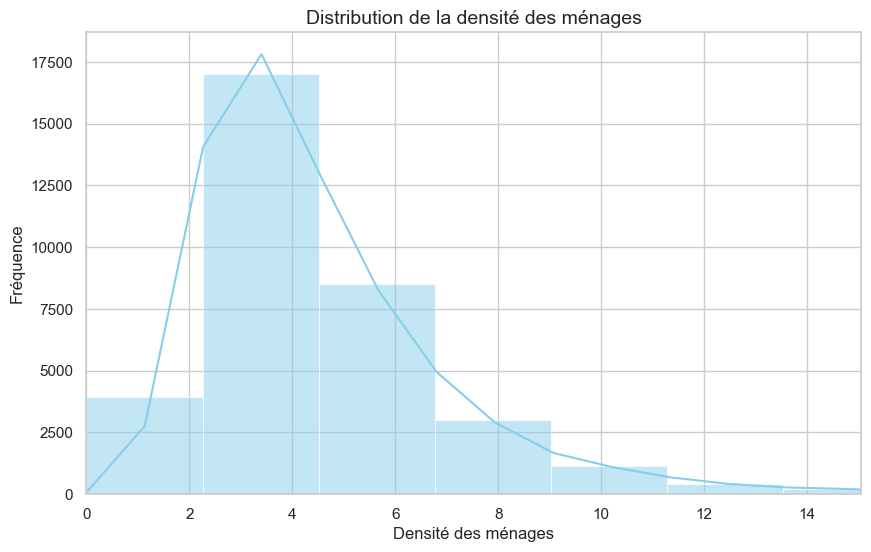

In [10]:
# Configuration du style visuel
sns.set_theme(style="whitegrid")

# Création de l'histogramme
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='densite_menages', bins=100, kde=True, color='skyblue')

# Ajout des titres et labels
plt.title('Distribution de la densité des ménages', fontsize=14)
plt.xlabel('Densité des ménages', fontsize=12)
plt.ylabel('Fréquence', fontsize=12)
plt.xlim(0, data['densite_menages'].quantile(0.99))  # Limiter l'axe x pour mieux visualiser la distribution
# Affichage
plt.show()


pour les ménages, on fait pareil, on transforme selon ces catégories : 
* 1-2 personne par foyer en moyenne 
* 3-4
* 5 et plus 

In [11]:
bins = [0, 2, 4, 100]

#Définition des noms des tranches
labels = ['1-2', '3-4', '5 et plus']

# right=True signifie que la borne droite est incluse. 
data['menage_moyen'] = pd.cut(data['densite_menages'], bins=bins, labels=labels, right=True)

# Suppression de l'ancienne colonne
data = data.drop('densite_menages', axis=1, errors='ignore')


On va transformer la variable agglomération en variable qualitative : 
* petit (agglomération $<20 000$)
* moyen (agglomération $<200 000$)
* grand  (agglomération $>200 000$)

c:\Users\anais\OneDrive - insa-toulouse.fr\Bureau\INSA\4A MA\ANALYSE_DONNEES\PROJET\AD_projet\.venv\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


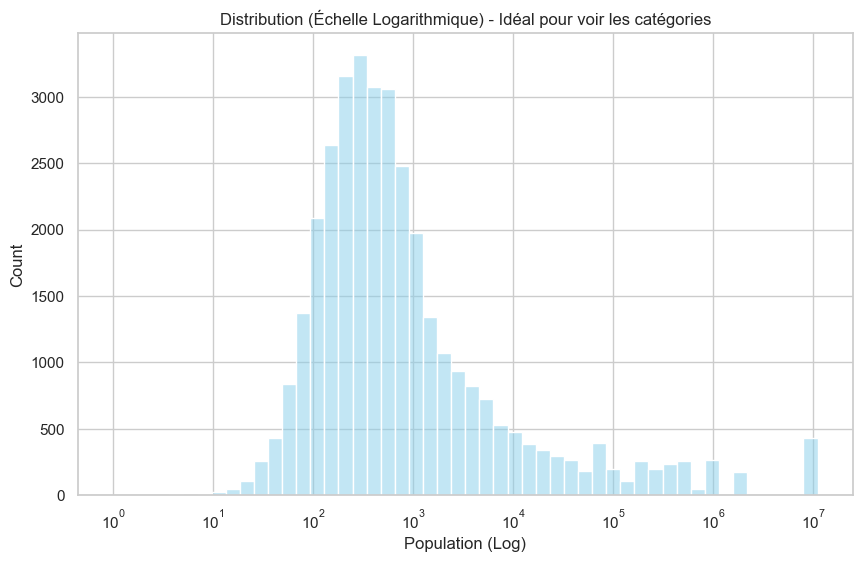

In [12]:
plt.figure(figsize=(10, 6))
# On utilise log_scale=True
sns.histplot(data=data, x='popagglo2022', bins=50, kde=True, log_scale=True, color='skyblue')

plt.title('Distribution (Échelle Logarithmique) - Idéal pour voir les catégories')
plt.xlabel('Population (Log)')
plt.show()

In [13]:
bins = [0, 15000, 200000, 200000000000]

#Définition des noms des tranches
labels = ['petite_agglo', 'moyenne_aglo', 'grande_agglo']

# right=True signifie que la borne droite est incluse. 
data['taille_agglo'] = pd.cut(data['popagglo2022'], bins=bins, labels=labels, right=True)

# Suppression de l'ancienne colonne
data = data.drop('popagglo2022', axis=1, errors='ignore')


C:\Users\anais\AppData\Local\Temp\ipykernel_10700\2911869468.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=data, x='taille_agglo', palette='viridis')


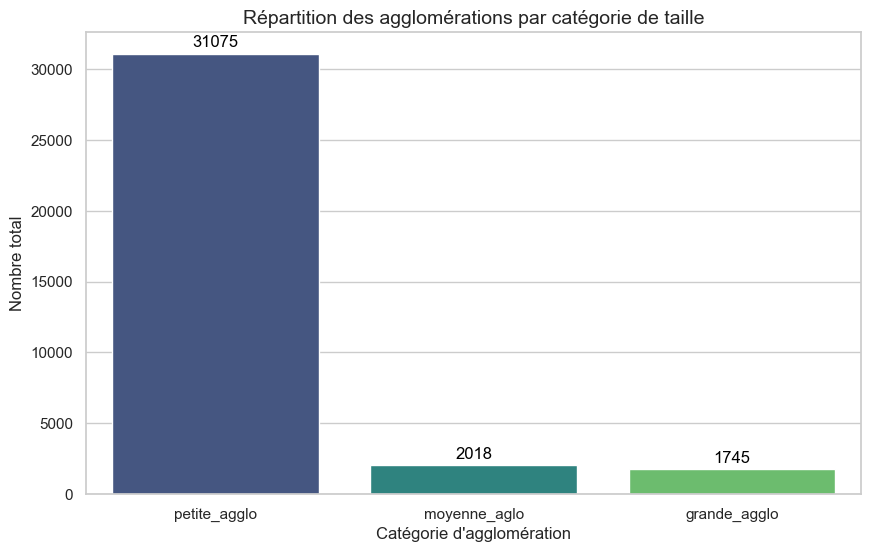

In [14]:

plt.figure(figsize=(10, 6))

# On utilise countplot pour compter le nombre d'agglomérations par catégorie
ax = sns.countplot(data=data, x='taille_agglo', palette='viridis')

# Ajout des chiffres au-dessus des barres pour plus de précision
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Répartition des agglomérations par catégorie de taille', fontsize=14)
plt.xlabel('Catégorie d\'agglomération', fontsize=12)
plt.ylabel('Nombre total', fontsize=12)

plt.show()

In [15]:
df_test = data.describe()

display(
    df_test.T.style.background_gradient(cmap='BuPu')
)
print("Nombre de colonnes :", len(data.columns))

c:\Users\anais\OneDrive - insa-toulouse.fr\Bureau\INSA\4A MA\ANALYSE_DONNEES\PROJET\AD_projet\.venv\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\anais\OneDrive - insa-toulouse.fr\Bureau\INSA\4A MA\ANALYSE_DONNEES\PROJET\AD_projet\.venv\Lib\site-packages\pandas\io\formats\style.py:4209: RuntimeWarning: invalid value encountered in scalar multiply
  norm = _matplotlib.colors.Normalize(smin - (rng * low), smax + (rng * high))


,count,mean,std,min,25%,50%,75%,max
pvoixAUG,34870.000000,0.012159,0.012696,0.000000,0.002354,0.009901,0.017368,0.347826
pvoixNUP,34870.000000,0.210458,0.106407,0.000000,0.144737,0.199559,0.264589,0.939394
pvoixDVG,34870.000000,0.041685,0.092373,0.000000,0.000000,0.000000,0.039261,0.891304
pvoixECO,34870.000000,0.021250,0.023127,0.000000,0.000000,0.016026,0.033080,0.491018
pvoixREG,34870.000000,0.020921,0.071194,0.000000,0.000000,0.000000,0.014085,1.000000
pvoixENS,34870.000000,0.219998,0.106020,0.000000,0.150685,0.216216,0.285714,0.875000
pvoixUDI,34870.000000,0.016614,0.048232,0.000000,0.000000,0.000000,0.000000,0.902439
pvoixLR,34870.000000,0.130345,0.135272,0.000000,0.024100,0.092949,0.191538,1.000000
pvoixDVD,34870.000000,0.047144,0.091957,0.000000,0.005917,0.018182,0.042553,1.000000
pvoixREC,34870.000000,0.037849,0.028447,0.000000,0.020439,0.033898,0.049751,0.421053


Nombre de colonnes : 77


On créé deux variables qualitatives : une variable qui donne le bord politique "gagnant" et le parti gagnant. 

In [16]:
# Définition des blocs à comparer
blocs = [
    'pvoteG', 'pvoteCG', 'pvoteC', 
    'pvoteCD', 'pvoteD',
]

#par commune : le bloc "vainqueur" et son score
data['Bloc_Dominant'] = data[blocs].idxmax(axis=1)
data['Bloc_Score'] = data[blocs].max(axis=1)

print(data['Bloc_Dominant'].unique())
partis =['pvoixAUG', 'pvoixNUP', 'pvoixDVG', 'pvoixECO', 'pvoixREG', 'pvoixENS', 'pvoixUDI', 'pvoixDVD', 'pvoixREC', 'pvoixRN', 'pvoixLR' ]
data['Parti_Dominant']= data[partis].idxmax(axis=1)
data['Parti_score']=data[partis].max(axis=1)


<ArrowStringArray>
['pvoteD', 'pvoteCD', 'pvoteC', 'pvoteG', 'pvoteCG']
Length: 5, dtype: str


In [17]:
# On utilise les doubles crochets [[]] pour sélectionner plusieurs colonnes
colonnes_qualitatives = ['tranche_age', 'menage_moyen', 'taille_agglo', 'Bloc_Dominant', 'Parti_Dominant']

# Conversion en object (ou 'category' pour économiser de la mémoire)
data[colonnes_qualitatives] = data[colonnes_qualitatives].astype(object)

# Vérification
print(data[colonnes_qualitatives].dtypes)

data.head()

tranche_age       object
menage_moyen      object
taille_agglo      object
Bloc_Dominant     object
Parti_Dominant    object
dtype: object


,dep,codecommune,pvoixAUG,pvoixNUP,pvoixDVG,pvoixECO,pvoixREG,pvoixENS,pvoixUDI,pvoixLR,...,perrsa2021,part_etranger,part_francais,tranche_age,menage_moyen,taille_agglo,Bloc_Dominant,Bloc_Score,Parti_Dominant,Parti_score
0,01,01001,0.011799,0.153392,0.047198,0.023599,0.000000,0.147493,0.097345,0.174041,...,0.056510,0.005089,0.987277,40-50,5 et plus,petite_agglo,pvoteD,0.318584,pvoixRN,0.256637
1,01,01002,0.031250,0.343750,0.000000,0.000000,0.000000,0.000000,0.000000,0.109375,...,0.030562,0.003759,0.962406,30-40,5 et plus,petite_agglo,pvoteCD,0.546875,pvoixDVD,0.437500
2,01,01004,0.016451,0.298106,0.008225,0.000000,0.013958,0.000000,0.000000,0.087488,...,0.645217,0.087881,0.890430,30-40,5 et plus,moyenne_aglo,pvoteCD,0.403091,pvoixDVD,0.312812
3,01,01005,0.008039,0.160772,0.038585,0.024116,0.000000,0.178457,0.093248,0.110932,...,0.050262,0.012603,0.931507,40-50,5 et plus,petite_agglo,pvoteD,0.376206,pvoixRN,0.316720
4,01,01006,0.050847,0.220339,0.000000,0.000000,0.000000,0.288136,0.000000,0.288136,...,0.038058,0.043860,0.938596,40-50,3-4,petite_agglo,pvoteC,0.288136,pvoixENS,0.288136


On va tenter une petite analyse des corrélations pour voir

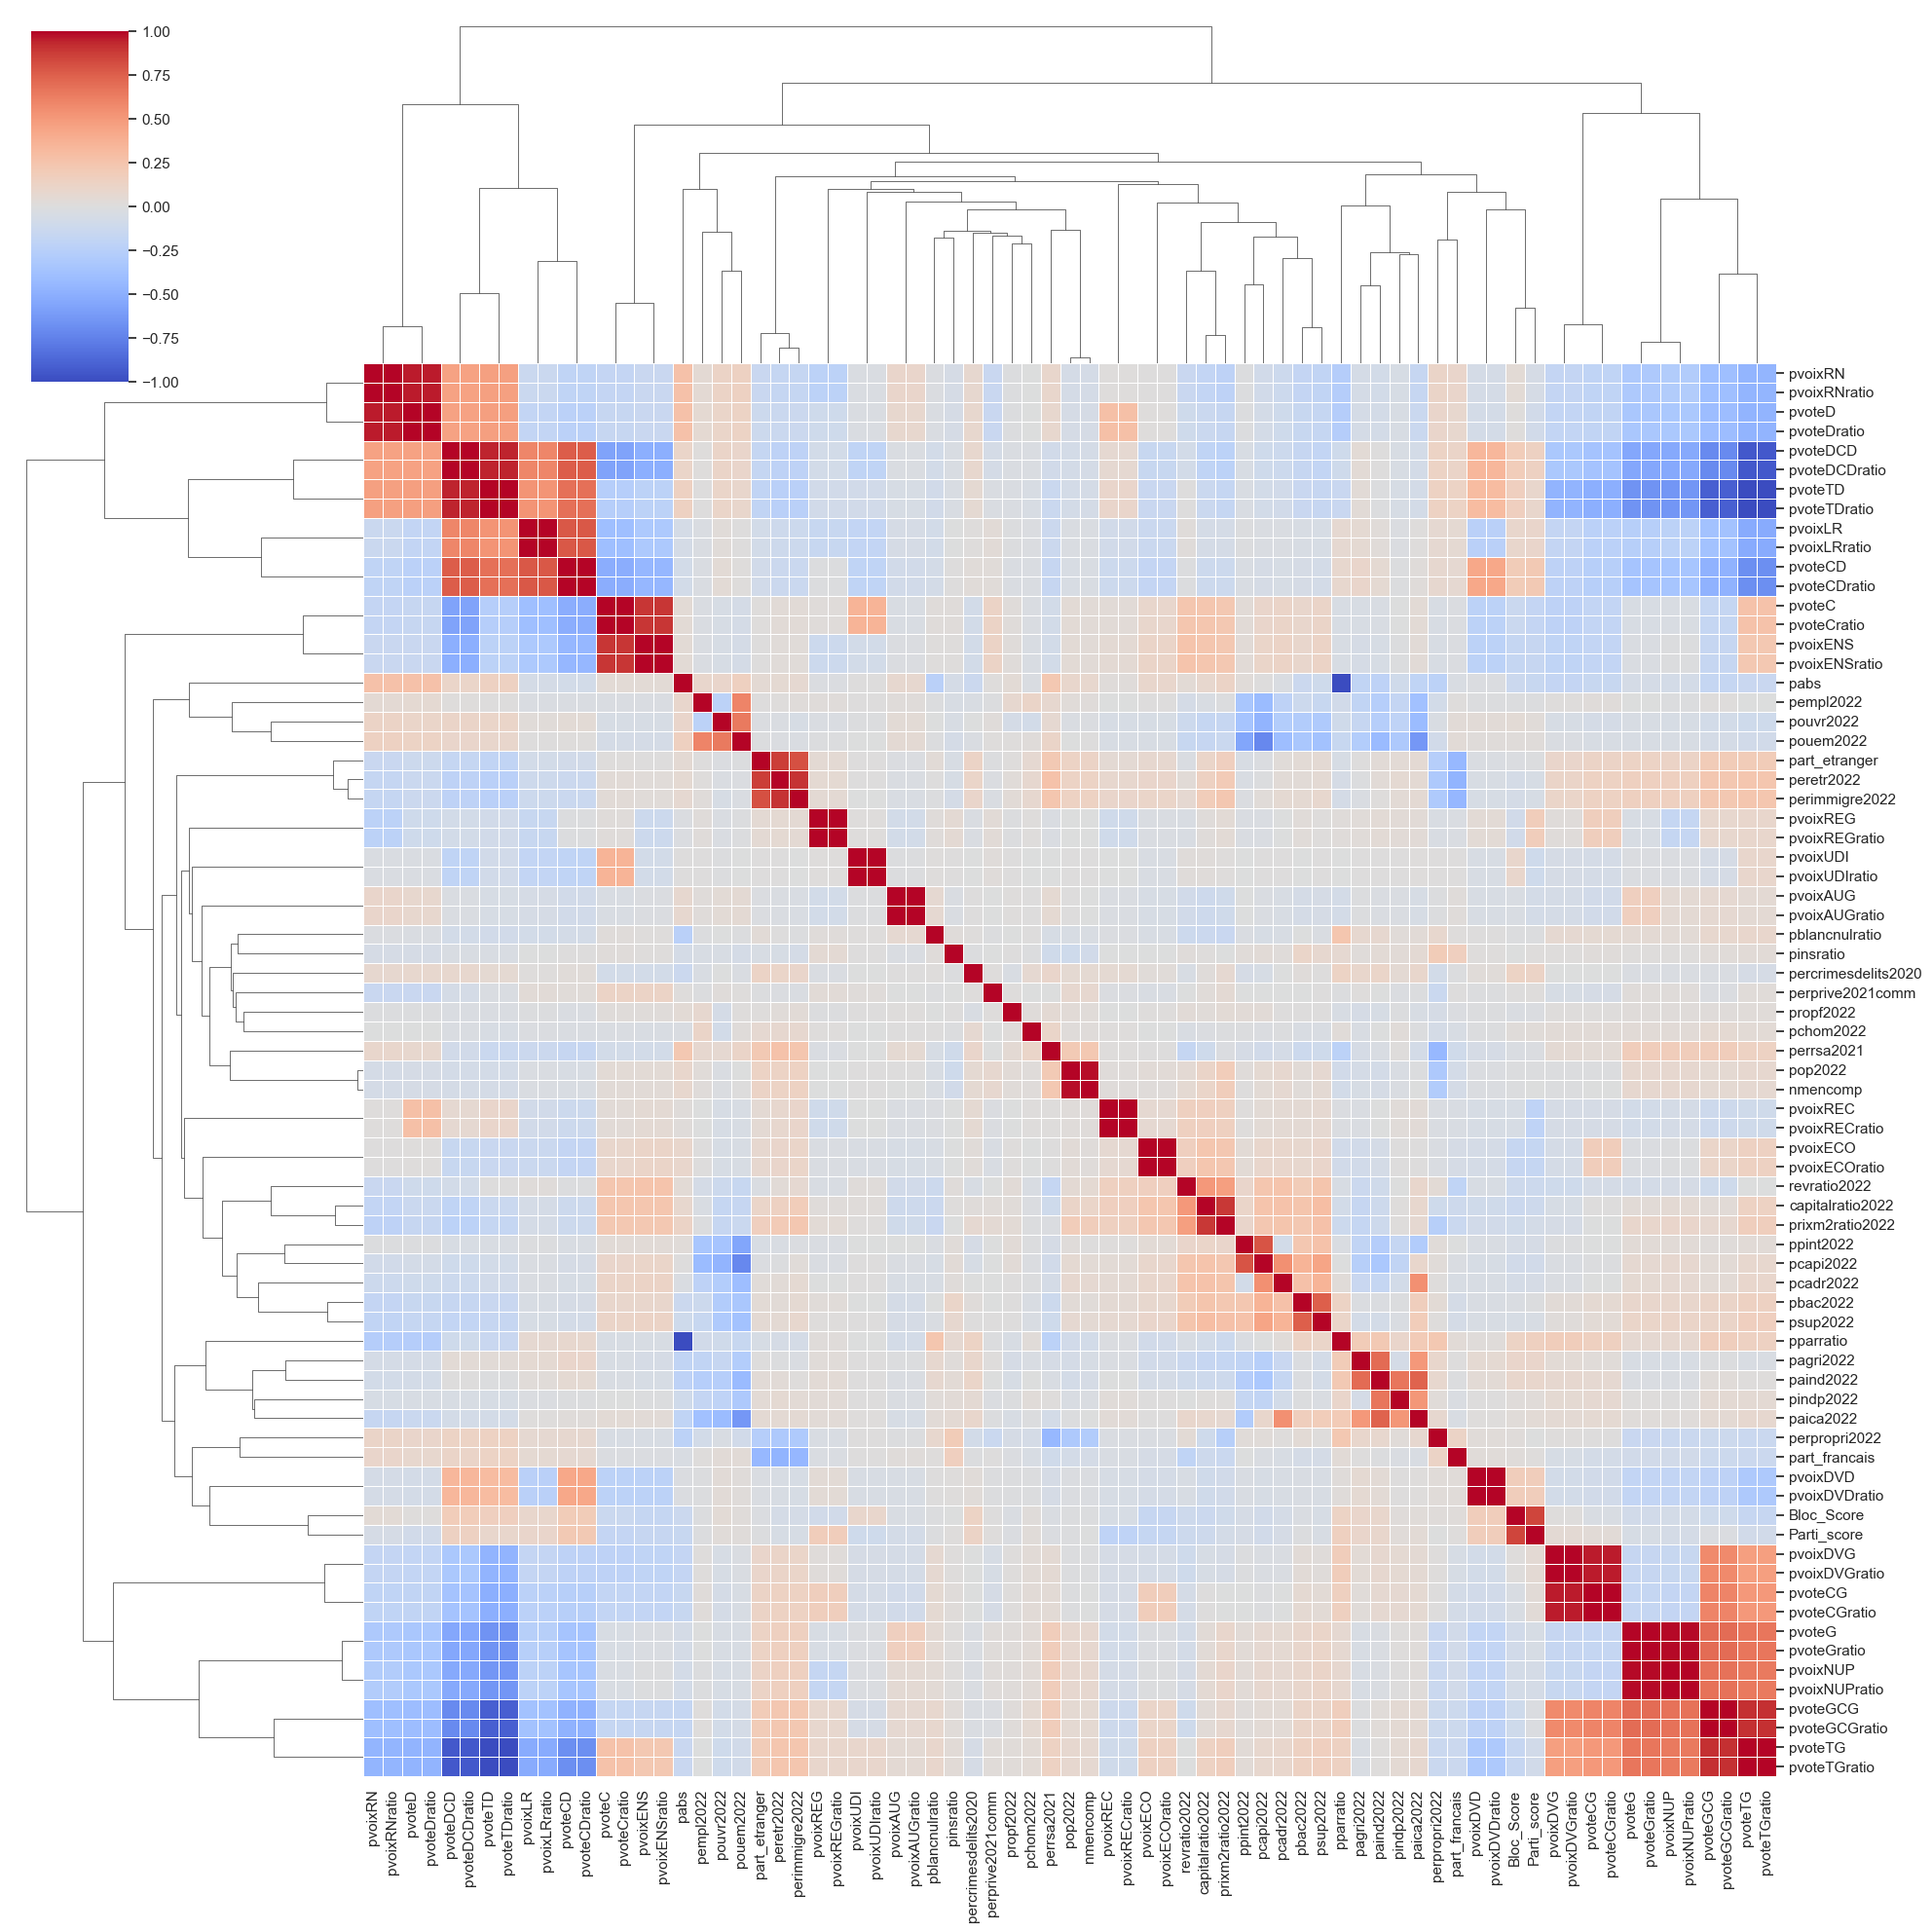

In [18]:
data_pd = data.select_dtypes(include='number')

# 2. Calcul de la corrélation (Pandas gère les NA par paire automatiquement)
corr_pd = data_pd.corr()

# 3. Sécurité : on remplace par 0 les NaN qui apparaîtraient si une variable a une variance nulle
corr_pd = corr_pd.fillna(0)

# 4. Génération du graphique
sns.clustermap(
    corr_pd, 
    annot=False, 
    cmap='coolwarm',
    vmax=1, vmin=-1,
    figsize=(20, 20),
    linewidths=.5,
    xticklabels=True,  
    yticklabels=True
)
plt.show()

Il faut analyser ces variables et en enlever plein : y'en a beaucoup qui sont inutiles

Typiquement l'interet de conserver pourcentage ET percentile ? Quel est le plus intéressant à garder ? 

Notre nombre de variables étant trop important pour avoir une lecture agréable de la matrice de correlation, on fait une liste contenant les correlations les plus élevées pour nous aider lors de l'analyse exploratoire (hors diagonale) (je sais pas si c'est utile à garder, je voulais surtout voir quels graphes faire)

In [19]:
corr_pairs = corr_pd.unstack() # on prend la matrice de corrélation et on la met sous forme de série
corr_df = pd.DataFrame(corr_pairs).reset_index()#on crée un DataFrame à partir de cette série
corr_df.columns = ['Var1', 'Var2', 'Corr']

corr_df = corr_df[corr_df['Var1'] != corr_df['Var2']] # on enlève les auto-corrélations (Var1 == Var2)

# certaines variables sont très proches (ex: pvoixRN et voixRN) et sont inutiles dans le classement des corrélations les plus fortes
def sont_trop_proches(v1, v2): # avec v1 et v2 les noms de deux variables
    # On enlève les préfixes courants pour comparer la racine du nom
    suffixes_a_ignorer = ['pvoix', 'voix', 'pvote', 'vote', 'per', 'ratio','2022', 'p'] # ces suffixes sont ajoutés à des variables parfois très proche 
    temp1, temp2 = v1.lower(), v2.lower()
    for s in suffixes_a_ignorer:
        temp1 = temp1.replace(s, '') # on remplace le suffixe par du vide 
        temp2 = temp2.replace(s, '')
    return temp1 == temp2 # si l'info principale est la même, alors on considère que les variables sont trop proches et redondantes

# On applique le filtre : on garde seulement si les racines sont différentes 
mask_proches = corr_df.apply(lambda x: sont_trop_proches(x['Var1'], x['Var2']), axis=1) # True si les variables sont trop proches, False sinon
corr_df_clean = corr_df[~mask_proches].copy() # on applique le masque inverse 

corr_df_clean['Abs_Corr'] = corr_df_clean['Corr'].abs() # on met en valeur absolue pour trier par la force de la corrélation, indépendamment du signe
top = corr_df_clean.sort_values(by='Abs_Corr', ascending=False).iloc[::2] # on en garde 1/2 pour éviter les doublons miroirs (A-B et B-A)
top.to_csv("classement_correlations.csv", index=False)
print("Fichier exporté ! ")

Fichier exporté ! 


Petit graphique pour voir : le vote a gauche en fonction du capital immobilier

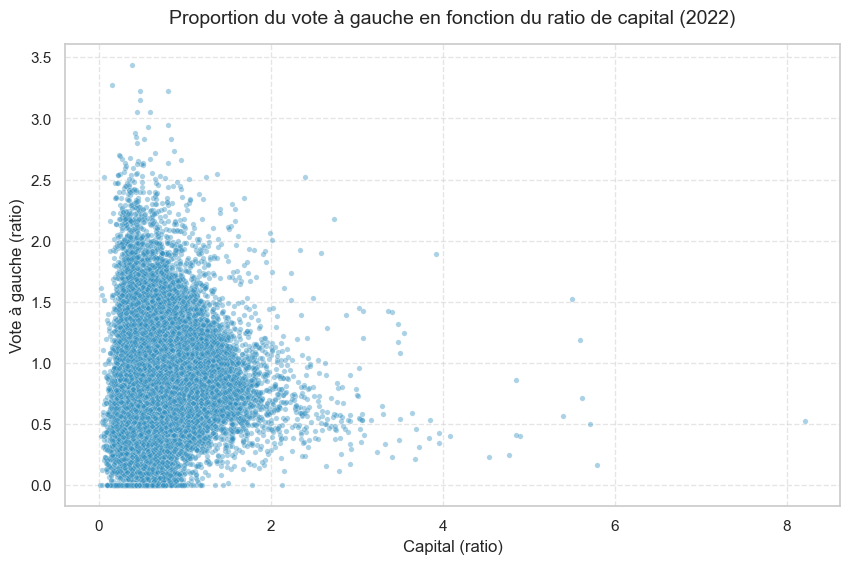

In [20]:
plt.figure(figsize=(10, 6))

# Création du nuage de points
sns.scatterplot(
    data=data, 
    x='capitalratio2022',  # Axe X : Capital (ratio)
    y='pvoteGratio',       # Axe Y : Proportion du vote à gauche
    alpha=0.4,             # Transparence des points (de 0 à 1) pour voir la densité
    s=15,                  # Taille des points
    color='#2b8cbe'        # Couleur des points
)

# Ajout d'un titre et de labels plus propres
plt.title('Proportion du vote à gauche en fonction du ratio de capital (2022)', fontsize=14, pad=15)
plt.xlabel('Capital (ratio)', fontsize=12)
plt.ylabel('Vote à gauche (ratio)', fontsize=12)

# Optionnel : Ajout d'une grille pour faciliter la lecture
plt.grid(True, linestyle='--', alpha=0.5)

# Affichage du graphique
plt.show()

On regarde maintenant le bloc dominant en fonction du capital

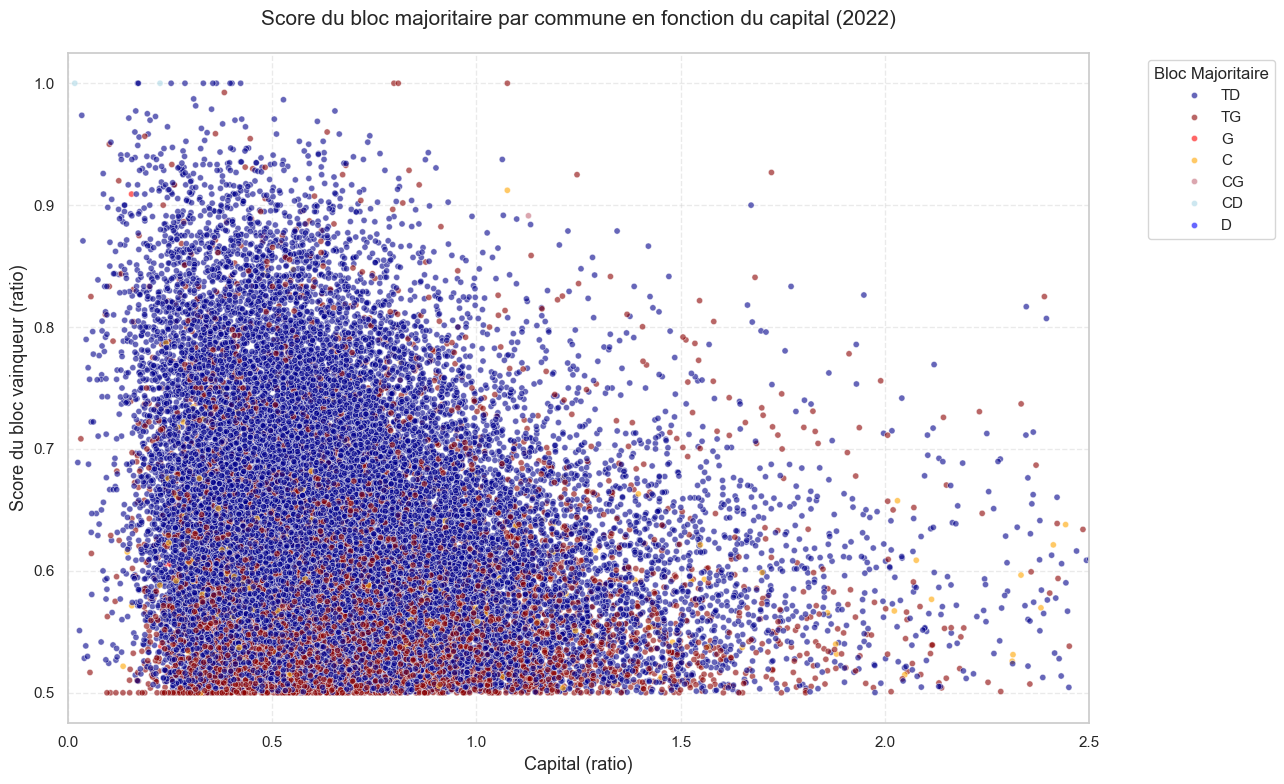

In [21]:

# Définition des blocs à comparer
blocs = [
    'pvoteG', 'pvoteCG', 'pvoteC', 
    'pvoteCD', 'pvoteD', 'pvoteTG', 'pvoteTD'
]

#par commune : le bloc "vainqueur" et son score
data['Bloc_Dominant'] = data[blocs].idxmax(axis=1)
data['Ratio_Dominant'] = data[blocs].max(axis=1)

# Définition d'une palette de couleurs politique 
couleurs_politiques = {
    'pvoteTG': '#8B0000',  # Rouge foncé (Très Gauche)
    'pvoteG': '#FF0000',   # Rouge (Gauche)
    'pvoteCG': "#C46B7A",  # Rose (Centre Gauche)
    'pvoteC': '#FFA500',   # Orange (Centre)
    'pvoteCD': '#ADD8E6',  # Bleu clair (Centre Droite)
    'pvoteD': '#0000FF',   # Bleu (Droite)
    'pvoteTD': '#00008B'   # Bleu foncé (Très Droite)
}

# 4. Configuration du graphique
plt.figure(figsize=(13, 8))

sns.scatterplot(
    data=data, 
    x='capitalratio2022',    # Axe X : capitalRatio2022
    y='Ratio_Dominant',      # Axe Y : Le score du vainqueur
    hue='Bloc_Dominant',     # Couleur : L'identité du vainqueur
    palette=couleurs_politiques, # Application des couleurs définies ci-dessus
    alpha=0.6,               # Transparence pour gérer la densité
    s=20,                    # Taille des points
    edgecolor='w',           # Petit contour blanc pour détacher les points
    linewidth=0.5
)

# 5. Titres et labels
plt.title('Score du bloc majoritaire par commune en fonction du capital (2022)', fontsize=15, pad=20)
plt.xlabel('Capital (ratio)', fontsize=13)
plt.ylabel('Score du bloc vainqueur (ratio)', fontsize=13)
plt.xlim(0,2.5) # on limite l'axe des x pour mieux voir la majorité des points (on pert quelques valeurs extrêmes mais c'est un choix pour la lisibilité)
# 6. Légende
# On nettoie les noms dans la légende (enlever 'pvote' et 'ratio')
handles, labels = plt.gca().get_legend_handles_labels()
clean_labels = [label.replace('pvote', '').replace('ratio', '') for label in labels]
plt.legend(handles, clean_labels, title='Bloc Majoritaire', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()

# Affichage
plt.show()

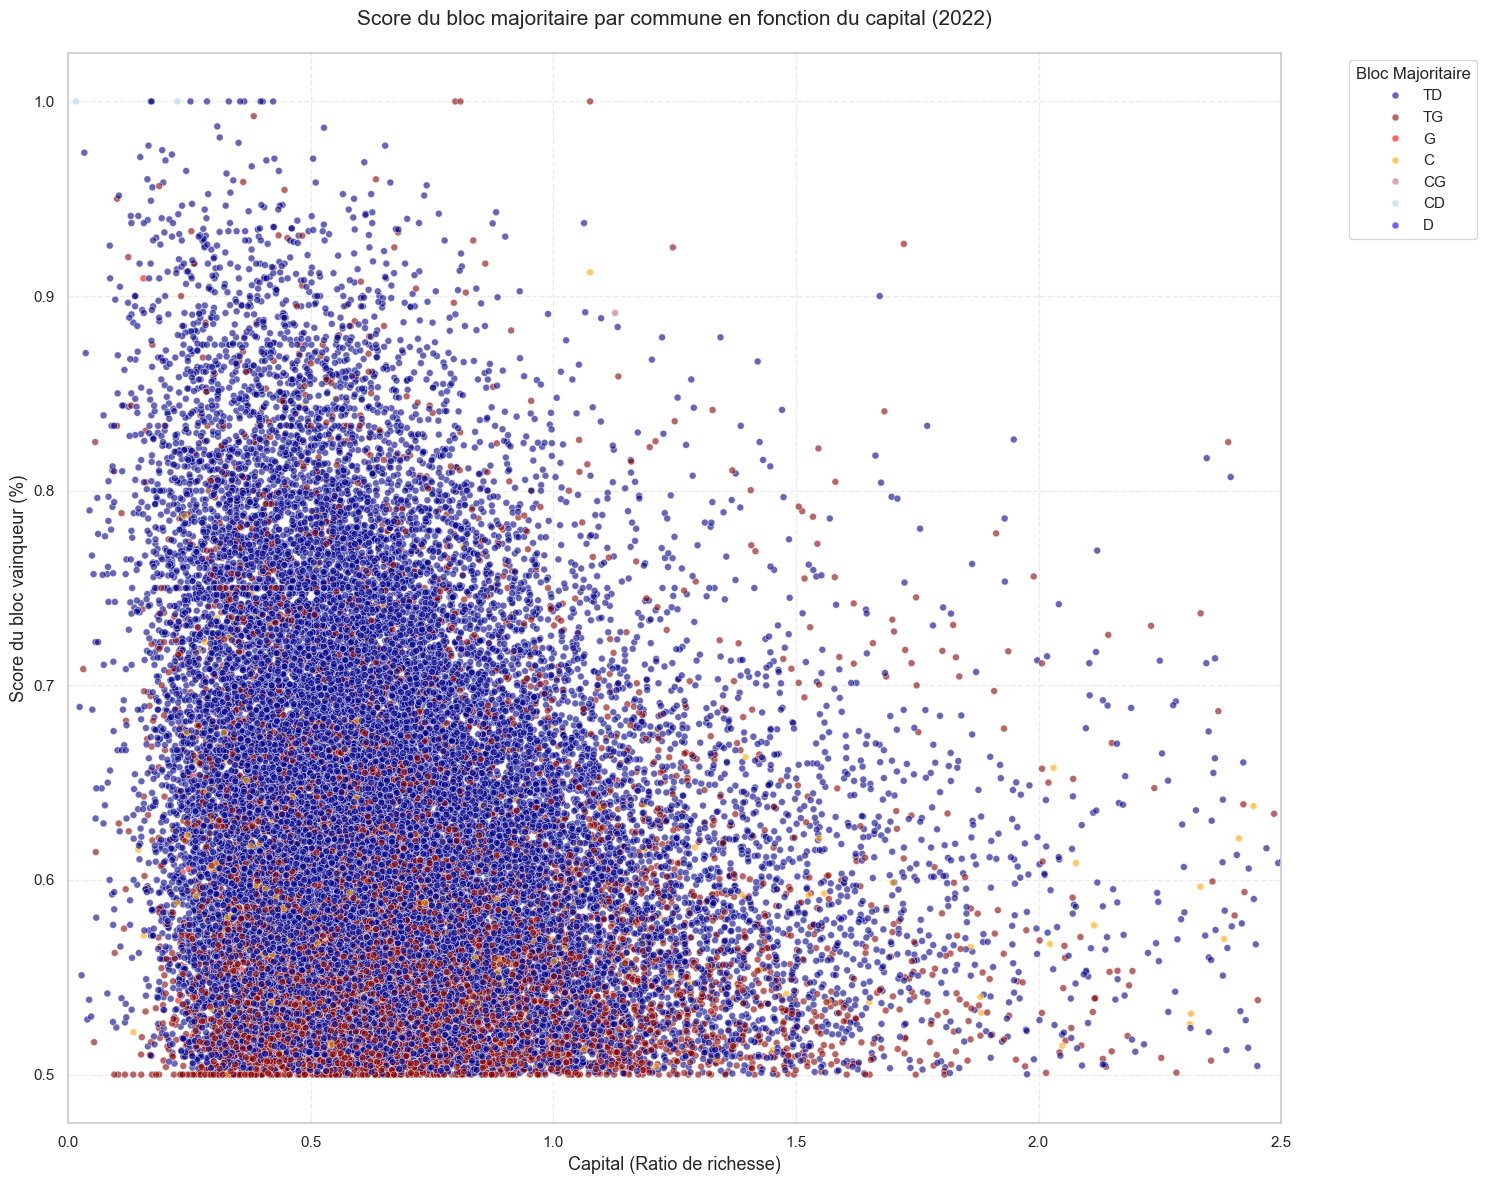

In [22]:
# 1. Définition des blocs à comparer (on enlève 'ratio')
# Note : j'utilise les noms de colonnes standards sans le suffixe ratio
blocs = [
    'pvoteG', 'pvoteCG', 'pvoteC', 
    'pvoteCD', 'pvoteD', 'pvoteTG', 'pvoteTD'
]

# 2. Détermination du bloc vainqueur et de son score en %
# idxmax trouve le nom de la colonne avec la valeur la plus haute
data['Bloc_Dominant'] = data[blocs].idxmax(axis=1)
# max récupère la valeur de ce score
data['Score_Vainqueur'] = data[blocs].max(axis=1)

# 3. Définition de la palette de couleurs
couleurs_politiques = {
    'pvoteTG': '#8B0000',  # Rouge foncé (Très Gauche)
    'pvoteG': '#FF0000',   # Rouge (Gauche)
    'pvoteCG': "#C46B7A",  # Rose (Centre Gauche)
    'pvoteC': '#FFA500',   # Orange (Centre)
    'pvoteCD': '#ADD8E6',  # Bleu clair (Centre Droite)
    'pvoteD': '#0000FF',   # Bleu (Droite)
    'pvoteTD': '#00008B'   # Bleu foncé (Très Droite)
}

# 4. Configuration du graphique
plt.figure(figsize=(15, 12))

sns.scatterplot(
    data=data, 
    x='capitalratio2022',    # On garde capitalratio2022 comme demandé
    y='Score_Vainqueur',     # Axe Y : Le score en % (ex: 35 pour 35%)
    hue='Bloc_Dominant',     # Couleur selon le vainqueur
    palette=couleurs_politiques,
    alpha=0.6,
    s=25,
    edgecolor='w',
    linewidth=0.5
)

# 5. Titres et labels
plt.title('Score du bloc majoritaire par commune en fonction du capital (2022)', fontsize=15, pad=20)
plt.xlabel('Capital (Ratio de richesse)', fontsize=13)
plt.ylabel('Score du bloc vainqueur (%)', fontsize=13)

# Limite de l'axe X pour la lisibilité
plt.xlim(0, 2.5)

# 6. Légende nettoyée
handles, labels = plt.gca().get_legend_handles_labels()
# On enlève 'pvote' pour que ce soit plus joli (ex: 'TG', 'G', 'CG')
clean_labels = [label.replace('pvote', '') for label in labels]
plt.legend(handles, clean_labels, title='Bloc Majoritaire', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()

# Affichage
plt.show()

In [23]:

# Définition des blocs à comparer
blocs = [
    'pvoteG', 'pvoteCG', 'pvoteC', 
    'pvoteCD', 'pvoteD', 'pvoteTG', 'pvoteTD'
]

#par commune : le bloc "vainqueur" et son score
data['Bloc_Dominant'] = data[blocs].idxmax(axis=1)
data['Ratio_Dominant'] = data[blocs].max(axis=1)

# Définition d'une palette de couleurs politique 
couleurs_politiques = {
    'pvoteTGratio': '#8B0000',  # Rouge foncé (Très Gauche)
    'pvoteGratio': '#FF0000',   # Rouge (Gauche)
    'pvoteCGratio': "#C46B7A",  # Rose (Centre Gauche)
    'pvoteCratio': '#FFA500',   # Orange (Centre)
    'pvoteCDratio': '#ADD8E6',  # Bleu clair (Centre Droite)
    'pvoteDratio': '#0000FF',   # Bleu (Droite)
    'pvoteTDratio': '#00008B'   # Bleu foncé (Très Droite)
}

# 4. Configuration du graphique
plt.figure(figsize=(13, 8))

sns.scatterplot(
    data=data, 
    x='part_etranger',    # Axe X : capitalRatio2022
    y='Ratio_Dominant',      # Axe Y : Le score du vainqueur
    hue='Bloc_Dominant',     # Couleur : L'identité du vainqueur
    palette=couleurs_politiques, # Application des couleurs définies ci-dessus
    alpha=0.6,               # Transparence pour gérer la densité
    s=20,                    # Taille des points
    edgecolor='w',           # Petit contour blanc pour détacher les points
    linewidth=0.5
)

# 5. Titres et labels
plt.title('Score du bloc majoritaire par commune en fonction de la part d\'étrangers', fontsize=15, pad=20)
plt.xlabel('Part d\'étrangers', fontsize=13)
plt.ylabel('Score du bloc vainqueur (ratio)', fontsize=13)
plt.xlim(0, 0.5)  # Limiter l'axe Y entre 0 et 0.5 pour mieux visualiser les différences
# 6. Légende
# On nettoie les noms dans la légende (enlever 'pvote' et 'ratio')
handles, labels = plt.gca().get_legend_handles_labels()
clean_labels = [label.replace('pvote', '').replace('ratio', '') for label in labels]
plt.legend(handles, clean_labels, title='Bloc Majoritaire', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()

# Affichage
plt.show()

ValueError: The palette dictionary is missing keys: {'pvoteD', 'pvoteTG', 'pvoteG', 'pvoteTD', 'pvoteC', 'pvoteCG', 'pvoteCD'}

<Figure size 1300x800 with 0 Axes>

In [ ]:
moy= data['pvoteDratio'].mean()
plt.figure(figsize=(10, 6))

# Création du nuage de points
sns.scatterplot(
    data=data, 
    x='part_etranger',  # Axe X : Capital (ratio)
    y='pvoteDratio',       # Axe Y : Proportion du vote à droite
    alpha=0.4,             # Transparence des points (de 0 à 1) pour voir la densité
    s=15,                  # Taille des points
    color='#2b8cbe'        # Couleur des points
)
plt.axhline(moy, color='red', linestyle='--', label=f'Moyenne vote à droite ({moy:.2f})')
plt.legend()
# Ajout d'un titre et de labels plus propres
plt.title('Proportion du vote à droite en fonction de la part d\'étrangers (2022)', fontsize=14, pad=15)
plt.xlabel('Part d\'étrangers', fontsize=12)
plt.ylabel('Vote à droite (ratio)', fontsize=12)
plt.xlim(0, 0.5)  # Limiter l'axe X entre 0 et 0.5 pour mieux visualiser les différences

# Optionnel : Ajout d'une grille pour faciliter la lecture
plt.grid(True, linestyle='--', alpha=0.5)

# Affichage du graphique
plt.show()


In [ ]:
moy= data['pvoteTDratio'].mean()
plt.figure(figsize=(10, 6))

# Création du nuage de points
sns.scatterplot(
    data=data, 
    x='part_etranger',  # Axe X : Capital (ratio)
    y='pvoteTDratio',       # Axe Y : Proportion du vote à droite
    alpha=0.4,             # Transparence des points (de 0 à 1) pour voir la densité
    s=15,                  # Taille des points
    color='#2b8cbe'        # Couleur des points
)
plt.axhline(moy, color='red', linestyle='--', label=f'Moyenne vote à Tdroite ({moy:.2f})')
plt.legend()
# Ajout d'un titre et de labels plus propres
plt.title('Proportion du vote à Tdroite en fonction de la part d\'étrangers (2022)', fontsize=14, pad=15)
plt.xlabel('Part d\'étrangers', fontsize=12)
plt.ylabel('Vote à Tdroite (ratio)', fontsize=12)
plt.xlim(0, 0.5)  # Limiter l'axe X entre 0 et 0.5 pour mieux visualiser les différences

# Optionnel : Ajout d'une grille pour faciliter la lecture
plt.grid(True, linestyle='--', alpha=0.5)

# Affichage du graphique
plt.show()

Est ce que les votes sont très étalés 

In [ ]:
moy= data['pvoteGratio'].mean()
plt.figure(figsize=(10, 6))

# Création du nuage de points
sns.scatterplot(
    data=data, 
    x='part_etranger',  # Axe X : Capital (ratio)
    y='pvoteGratio',       # Axe Y : Proportion du vote à droite
    alpha=0.4,             # Transparence des points (de 0 à 1) pour voir la densité
    s=15,                  # Taille des points
    color='#2b8cbe'        # Couleur des points
)
plt.axhline(moy, color='red', linestyle='--', label=f'Moyenne vote à gauche ({moy:.2f})')
plt.legend()
# Ajout d'un titre et de labels plus propres
plt.title('Proportion du vote à gauche en fonction de la part d\'étrangers (2022)', fontsize=14, pad=15)
plt.xlabel('Part d\'étrangers', fontsize=12)
plt.ylabel('Vote à gauche (ratio)', fontsize=12)
plt.xlim(0, 0.5)  # Limiter l'axe X entre 0 et 0.5 pour mieux visualiser les différences

# Optionnel : Ajout d'une grille pour faciliter la lecture
plt.grid(True, linestyle='--', alpha=0.5)

# Affichage du graphique
plt.show()

In [ ]:
# Liste des blocs à comparer
blocs = ['pvoteTGratio','pvoteGratio', 'pvoteCGratio', 'pvoteCratio', 'pvoteCDratio', 'pvoteDratio','pvoteTDratio']

plt.figure(figsize=(12, 6))
sns.boxplot(data=data[blocs], palette="Set3")

plt.title("Distribution des scores par bloc politique", fontsize=14)
plt.ylabel("Ratio des voix")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Ce graphe permet de voir si les votes font consensus ou non. Par exemple, le CG a une médiane assez basse, mais on observe qu'elle a une variance plus importante, et beaucoup de valeurs aberrantes, ce qui semble montrer que quand il gagne, il gagne fort. Le TD comme le TG par exemple semble être voté partout un peu pareil 

In [ ]:
plt.figure(figsize=(10, 6))

# On trace la distribution du Centre-Gauche
sns.histplot(data['pvoteCGratio'], kde=True, color='pink', label='Centre-Gauche')
# On peut superposer avec un autre pour comparer, ex: la Droite
sns.histplot(data['pvoteDratio'], kde=True, color='blue', label='Droite', alpha=0.3)

plt.title("Densité des votes : Y a-t-il un consensus ?")
plt.xlabel("Score obtenu dans la commune")
plt.ylabel("Nombre de communes")
plt.legend()
plt.show()

pour confirmer un peu ce qu'on a vu. Score bas lié à l'immensité de la barre à gauche (+ toute la distribution est centrée vers la gauche) mais varaince élevée à cause de la trainée. La droite est  une jolie gaussienne 

je trouve ça un peu bizarre nos données pour le centre gauche 

Est ce que l'abstention / le vote nul fait gagner certains partis ? 

In [ ]:
blocs = [
    'pvoteGratio', 'pvoteCGratio', 'pvoteCratio', 
    'pvoteCDratio', 'pvoteDratio', 'pvoteTGratio', 'pvoteTDratio'
]

#par commune : le bloc "vainqueur" et son score
data['Bloc_Dominant'] = data[blocs].idxmax(axis=1)
data['Ratio_Dominant'] = data[blocs].max(axis=1)

# Définition d'une palette de couleurs politique 
couleurs_politiques = {
    'pvoteTGratio': '#8B0000',  # Rouge foncé (Très Gauche)
    'pvoteGratio': '#FF0000',   # Rouge (Gauche)
    'pvoteCGratio': "#C46B7A",  # Rose (Centre Gauche)
    'pvoteCratio': '#FFA500',   # Orange (Centre)
    'pvoteCDratio': '#ADD8E6',  # Bleu clair (Centre Droite)
    'pvoteDratio': '#0000FF',   # Bleu (Droite)
    'pvoteTDratio': '#00008B'   # Bleu foncé (Très Droite)
}

# 4. Configuration du graphique
plt.figure(figsize=(13, 8))

sns.scatterplot(
    data=data, 
    x='pblancnulratio',    # Axe X : capitalRatio2022
    y='Ratio_Dominant',      # Axe Y : Le score du vainqueur
    hue='Bloc_Dominant',     # Couleur : L'identité du vainqueur
    palette=couleurs_politiques, # Application des couleurs définies ci-dessus
    alpha=0.6,               # Transparence pour gérer la densité
    s=20,                    # Taille des points
    edgecolor='w',           # Petit contour blanc pour détacher les points
    linewidth=0.5
)

# 5. Titres et labels
plt.title('Score du bloc majoritaire par commune en fonction de la part de votes blancs et nuls', fontsize=15, pad=20)
plt.xlabel('Part de votes blancs et nuls (ratio)', fontsize=13)
plt.ylabel('Score du bloc vainqueur (ratio)', fontsize=13)
plt.xlim(0,15)
# 6. Légende
# On nettoie les noms dans la légende (enlever 'pvote' et 'ratio')
handles, labels = plt.gca().get_legend_handles_labels()
clean_labels = [label.replace('pvote', '').replace('ratio', '') for label in labels]
plt.legend(handles, clean_labels, title='Bloc Majoritaire', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()

# Affichage
plt.show()

In [ ]:
blocs = [
    'pvoteGratio', 'pvoteCGratio', 'pvoteCratio', 
    'pvoteCDratio', 'pvoteDratio', 'pvoteTGratio', 'pvoteTDratio'
]

#par commune : le bloc "vainqueur" et son score
data['Bloc_Dominant'] = data[blocs].idxmax(axis=1)
data['Ratio_Dominant'] = data[blocs].max(axis=1)

# Définition d'une palette de couleurs politique 
couleurs_politiques = {
    'pvoteTGratio': '#8B0000',  # Rouge foncé (Très Gauche)
    'pvoteGratio': '#FF0000',   # Rouge (Gauche)
    'pvoteCGratio': "#C46B7A",  # Rose (Centre Gauche)
    'pvoteCratio': '#FFA500',   # Orange (Centre)
    'pvoteCDratio': '#ADD8E6',  # Bleu clair (Centre Droite)
    'pvoteDratio': '#0000FF',   # Bleu (Droite)
    'pvoteTDratio': '#00008B'   # Bleu foncé (Très Droite)
}

# 4. Configuration du graphique
plt.figure(figsize=(13, 8))

sns.scatterplot(
    data=data, 
    x='pabs',    # Axe X : capitalRatio2022
    y='Ratio_Dominant',      # Axe Y : Le score du vainqueur
    hue='Bloc_Dominant',     # Couleur : L'identité du vainqueur
    palette=couleurs_politiques, # Application des couleurs définies ci-dessus
    alpha=0.6,               # Transparence pour gérer la densité
    s=20,                    # Taille des points
    edgecolor='w',           # Petit contour blanc pour détacher les points
    linewidth=0.5
)

# 5. Titres et labels
plt.title('Score du bloc majoritaire par commune en fonction de l\'abstention', fontsize=15, pad=20)
plt.xlabel('Proportion d\'abstention (ratio)', fontsize=13)
plt.ylabel('Score du bloc vainqueur (ratio)', fontsize=13)

# 6. Légende
# On nettoie les noms dans la légende (enlever 'pvote' et 'ratio')
handles, labels = plt.gca().get_legend_handles_labels()
clean_labels = [label.replace('pvote', '').replace('ratio', '') for label in labels]
plt.legend(handles, clean_labels, title='Bloc Majoritaire', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()

# Affichage
plt.show()

zoom sur les 1000 plus FORT TAUX

In [ ]:
absten=data.sort_values(by='pabs', ascending=False).head(1000) 
blocs = [
    'pvoteGratio', 'pvoteCGratio', 'pvoteCratio', 
    'pvoteCDratio', 'pvoteDratio', 'pvoteTGratio', 'pvoteTDratio'
]

#par commune : le bloc "vainqueur" et son score
data['Bloc_Dominant'] = data[blocs].idxmax(axis=1)
data['Ratio_Dominant'] = data[blocs].max(axis=1)

# Définition d'une palette de couleurs politique 
couleurs_politiques = {
    'pvoteTGratio': '#8B0000',  # Rouge foncé (Très Gauche)
    'pvoteGratio': '#FF0000',   # Rouge (Gauche)
    'pvoteCGratio': "#C46B7A",  # Rose (Centre Gauche)
    'pvoteCratio': '#FFA500',   # Orange (Centre)
    'pvoteCDratio': '#ADD8E6',  # Bleu clair (Centre Droite)
    'pvoteDratio': '#0000FF',   # Bleu (Droite)
    'pvoteTDratio': '#00008B'   # Bleu foncé (Très Droite)
}

# 4. Configuration du graphique
plt.figure(figsize=(13, 8))

sns.scatterplot(
    data=absten, 
    x='pabs',    # Axe X : capitalRatio2022
    y='Ratio_Dominant',      # Axe Y : Le score du vainqueur
    hue='Bloc_Dominant',     # Couleur : L'identité du vainqueur
    palette=couleurs_politiques, # Application des couleurs définies ci-dessus
    alpha=1,               # Transparence pour gérer la densité
    s=20,                    # Taille des points
    edgecolor='w',           # Petit contour blanc pour détacher les points
    linewidth=0.5
)

# 5. Titres et labels
plt.title('Score du bloc majoritaire par commune en fonction de l\'abstention (Zoom)', fontsize=15, pad=20)
plt.xlabel('Proportion d\'abstention (ratio)', fontsize=13)
plt.ylabel('Score du bloc vainqueur (ratio)', fontsize=13)

# 6. Légende
# On nettoie les noms dans la légende (enlever 'pvote' et 'ratio')
handles, labels = plt.gca().get_legend_handles_labels()
clean_labels = [label.replace('pvote', '').replace('ratio', '') for label in labels]
plt.legend(handles, clean_labels, title='Bloc Majoritaire', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()

# Affichage
plt.show()

In [ ]:
import pandas as pd

# 1. On isole les 1000 communes où l'abstention (pabs) est la plus forte
absten = data.sort_values(by='pabs', ascending=False).head(1000)

# 2. Liste des blocs de vote (sans ratio comme demandé précédemment)
blocs_vote = ['voteTG', 'pvoteG', 'pvoteCG', 'pvoteC', 'pvoteCD', 'pvoteD', 'pvoteTD']

# 3. Calcul de la moyenne pour ces communes VS la moyenne globale
moyenne_absten = absten[blocs_vote].mean()
moyenne_totale = data[blocs_vote].mean()

# 4. Création du tableau comparatif
recap_votes = pd.DataFrame({
    'Moyenne_Top_Abstention': moyenne_absten,
    'Moyenne_Toute_France': moyenne_totale,
    'Ecart': moyenne_absten - moyenne_totale
})

print("--- RÉCAPITULATIF DES VOTES DANS LES 1000 COMMUNES LES PLUS ABSTENTIONNISTES ---")
print(recap_votes.sort_values(by='Ecart', ascending=False))

In [ ]:

# 1. Préparation des données (si pas déjà fait)
absten = data.sort_values(by='pabs', ascending=False).head(1000)
blocs_vote = ['pvoteTGratio', 'pvoteGratio', 'pvoteCGratio', 'pvoteCratio', 'pvoteCDratio', 'pvoteDratio', 'pvoteTDratio']

# 2. Calcul des moyennes
moyenne_absten = absten[blocs_vote].mean()
moyenne_totale = data[blocs_vote].mean()

# 3. Création du DataFrame pour le graphique (Index = Blocs)
df_plot = pd.DataFrame({
    'Top 1000 Abstention': moyenne_absten,
    'Moyenne France': moyenne_totale
})

# 4. Génération du graphique
# On définit des couleurs contrastées pour bien distinguer les deux groupes
ax = df_plot.plot(kind='bar', figsize=(14, 7), color=["#A2DC56", "#F071B9"], width=0.8)

# 5. Personnalisation esthétique
plt.title("Comparaison du vote par bloc : Zones d'Abstention vs France Entière", fontsize=15, pad=20)
plt.ylabel("Score moyen (%)", fontsize=12)
plt.xlabel("Blocs Politiques", fontsize=12)

# On nettoie les étiquettes de l'axe X (enlever 'pvote')
plt.xticks(range(len(blocs_vote)), [b.replace('pvote', '') for b in blocs_vote], rotation=0)

plt.legend(title="Zones comparées", fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Ajout des valeurs au-dessus des barres pour plus de précision
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=9)

plt.tight_layout()
plt.show()

que votent les villes les plus riches ? 

In [ ]:
riche=data.sort_values(by='capitalratio2022', ascending=False).head(10)
pauvre=data.sort_values(by='capitalratio2022', ascending=True).head(10)

blocs_vote = [
    'pvoixNUPratio',   
    'pvoixDVGratio',   
    'pvoixENSratio',   
    'pvoixLRratio',    
    'pvoixDVDratio',   
    'pvoixRNratio',   
    'pvoixRECratio'    
]

moyenne_nationale = data[blocs_vote].mean().to_frame().T
moyenne_nationale['nomcommune'] = 'MOYENNE GLOBALE' # Label pour la barre

# 3. Fusion des deux pour le graphique
# On met la moyenne en premier pour qu'elle apparaisse en haut (ou en bas selon l'ordre)
df_plot = pd.concat([moyenne_nationale, riche], axis=0, sort=False)


couleurs = {
    'pvoixNUPratio': '#FF3333',   # Rouge vif
    'pvoixDVGratio': '#FF9999',   # Rose
    'pvoixENSratio': '#FFCC00',   # Jaune/Orange
    'pvoixLRratio': '#3366CC',    # Bleu
    'pvoixDVDratio': '#ADC2EB',   # Bleu clair
    'pvoixRNratio': '#000080',    # Bleu marine
    'pvoixRECratio': '#000033'    # Bleu très foncé
}

# 4. Configuration du graphique
# On utilise la méthode plot() de Pandas qui est très pratique pour les barres empilées
df_plot.set_index('codecommune')[blocs_vote].plot(
    kind='barh',        # Barres horizontales pour mieux lire les noms
    stacked=True,       # Empilées pour faire 100%
    color=[couleurs[b] for b in blocs_vote], # Application de la palette
    figsize=(14, 8),
    width=0.8
)

# 5. Titres et labels
plt.title('Structure du vote dans les 10 communes au plus fort capital (2022)', fontsize=16, pad=20)
plt.xlabel('Part des suffrages exprimés (%)', fontsize=13)
plt.ylabel('Code Commune (Top 10 Capital)', fontsize=13)

# 6. Légende
# On nettoie les labels (enlever 'pvoix') pour la légende
handles, labels = plt.gca().get_legend_handles_labels()
clean_labels = [label.replace('pvoix', '') for label in labels]
plt.legend(handles, clean_labels, title='Bloc Politique', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

# Affichage
plt.show()

In [ ]:
pauvre=data.sort_values(by='capitalratio2022', ascending=True).head(10)


moyenne_nationale = data[blocs_vote].mean().to_frame().T
moyenne_nationale['nomcommune'] = 'MOYENNE GLOBALE' # Label pour la barre

# 3. Fusion des deux pour le graphique
# On met la moyenne en premier pour qu'elle apparaisse en haut (ou en bas selon l'ordre)
df_plot = pd.concat([moyenne_nationale, pauvre], axis=0, sort=False)

# 4. Configuration du graphique
# On utilise la méthode plot() de Pandas qui est très pratique pour les barres empilées
df_plot.set_index('codecommune')[blocs_vote].plot(
    kind='barh',        # Barres horizontales pour mieux lire les noms
    stacked=True,       # Empilées pour faire 100%
    color=[couleurs[b] for b in blocs_vote], # Application de la palette
    figsize=(14, 8),
    width=0.8
)

# 5. Titres et labels
plt.title('Structure du vote dans les 10 communes au plus faible capital (2022)', fontsize=16, pad=20)
plt.xlabel('Part des suffrages exprimés (%)', fontsize=13)
plt.ylabel('Code Commune (Top 10 Capital)', fontsize=13)

# 6. Légende
# On nettoie les labels (enlever 'pvoix') pour la légende
handles, labels = plt.gca().get_legend_handles_labels()
clean_labels = [label.replace('pvoix', '') for label in labels]
plt.legend(handles, clean_labels, title='Bloc Politique', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

# Affichage
plt.show()

In [ ]:
print(data['Bloc_Dominant'].unique())

on veut faire une carte de la france en fonction du vainqueur :)

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd

# 1. Chargement des contours des communes françaises (GeoJSON simplifié)
url_geojson = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/communes.geojson"
france_communes = gpd.read_file(url_geojson)

# 2. Préparation des données
# On s'assure que le code commune est sur 5 caractères (ex: 01001)
data['codecommune'] = data['codecommune'].astype(str).str.zfill(5)

# 3. Fusion des données statistiques avec la géométrie
carte_data = france_communes.merge(data, left_on='code', right_on='codecommune')

# 4. Configuration des couleurs
couleurs_dict = {
    'pvoteG': '#FF0000',  # Rouge
    'pvoteCG': "#C46B7A", # Rose
    'pvoteC': '#FFA500',  # Orange
    'pvoteCD': '#ADD8E6', # Bleu clair
    'pvoteD': '#0000FF',  # Bleu
}

# 5. Gestion des catégories pour la légende et éviter les erreurs
# On récupère les valeurs uniques présentes dans la colonne finale
valeurs_reelles = carte_data['Bloc_Dominant'].unique().tolist()

# On définit l'ordre logique pour la légende
ordre_logique = ['pvoteG', 'pvoteCG', 'pvoteC', 'pvoteCD', 'pvoteD']

# On ne garde que les catégories qui existent vraiment dans le dataset fusionné
categories_finales = [b for b in ordre_logique if b in valeurs_reelles]

# Sécurité : si une valeur inattendue apparaît, on l'ajoute à la fin
for v in valeurs_reelles:
    if v not in categories_finales:
        categories_finales.append(v)

# Création de la palette de couleurs (Colormap)
couleurs_liste = [couleurs_dict.get(cat, '#CCCCCC') for cat in categories_finales]
cmap_custom = mcolors.ListedColormap(couleurs_liste)

# 6. Affichage de la carte
fig, ax = plt.subplots(1, 1, figsize=(15, 15), dpi=150)

carte_data.plot(
    column='Bloc_Dominant', 
    ax=ax, 
    categorical=True,
    categories=categories_finales, 
    cmap=cmap_custom,              
    legend=True, 
    linewidth=0,          # Supprime les traits blancs
    edgecolor='none',     # Supprime les traits blancs
    legend_kwds={
        'title': "Blocs Politiques",
        'loc': 'upper left',
        'bbox_to_anchor': (1, 1),
        'frameon': False
    }
)


# 7. Finalisation
ax.set_axis_off()
plt.title("Carte de France par Bloc Dominant (2022)", fontsize=18, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

In [ ]:
print(data['Parti_Dominant'].unique())

In [ ]:
# 1. Chargement & 2. Préparation (inchangés)
url_geojson = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/communes.geojson"
france_communes = gpd.read_file(url_geojson)
data['codecommune'] = data['codecommune'].astype(str).str.zfill(5)
carte_data = france_communes.merge(data, left_on='code', right_on='codecommune')

# 4. Configuration des couleurs (Vérifie bien que ces noms sont dans 'Parti_Dominant')
couleurs = {
    'pvoixAUG': '#8B0000',    # Rouge sombre / Bordeaux (Extrême Gauche)
    'pvoixNUP': '#FF3333',    # Rouge vif (NUPES)
    'pvoixDVG': '#FF9999',    # Rose (Divers Gauche)
    'pvoixENS': '#FFCC00',    # Jaune/Orange (Ensemble / Majorité Présidentielle)
    'pvoixUDI': '#99CCFF',    # Bleu ciel très clair ou Orange (souvent entre centre et droite)
    'pvoixREG': '#006633',    # Vert forêt (Régionalistes)
    'pvoixLR': '#3366CC',     # Bleu (Les Républicains)
    'pvoixDVD': '#ADC2EB',    # Bleu clair (Divers Droite)
    'pvoixRN': '#000080',     # Bleu marine (Rassemblement National)
    'pvoixREC': '#000033',    # Bleu nuit / Noir (Reconquête)
}

# 5. Gestion des catégories
valeurs_reelles = carte_data['Parti_Dominant'].unique().tolist()

# Correction : Ajout de la virgule entre 'pvoixENS' et 'pvoixLR'
ordre_logique = ['pvoixAUG','pvoixNUP','pvoixDVG','pvoixENS', 'pvoixLR','pvoixDVD','pvoixRN','pvoixREC','pvoixUDI','pvoixREG']

categories_finales = [b for b in ordre_logique if b in valeurs_reelles]
for v in valeurs_reelles:
    if v not in categories_finales:
        categories_finales.append(v)

# CORRECTION ICI : On utilise bien 'couleurs' (le nom de ton dictionnaire)
couleurs_liste = [couleurs.get(cat, '#CCCCCC') for cat in categories_finales]
cmap_custom = mcolors.ListedColormap(couleurs_liste)

# 6. Affichage
fig, ax = plt.subplots(1, 1, figsize=(15, 15), dpi=150)

carte_data.plot(
    column='Parti_Dominant', 
    ax=ax, 
    categorical=True,
    categories=categories_finales, 
    cmap=cmap_custom,              
    legend=True, 
    linewidth=0,          
    edgecolor='none',     
    legend_kwds={
        'title': "Partis Politiques",
        'loc': 'upper left',
        'bbox_to_anchor': (1, 1),
        'frameon': False
    }
)

ax.set_axis_off()
plt.title("Carte de France par Parti Dominant (2022)", fontsize=18, fontweight='bold', pad=20)
plt.show()

In [ ]:
print(f"Nombre de communes dans data : {len(data)}")
print(f"Nombre de communes après fusion : {len(carte_data)}")

est ce qu'on peut deviner quel type d'extreme droite ils vont voter les riches 

# Clustering : DBSCAN

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


data_dbscan = data.copy()  # Pour éviter de modifier l'original

ACP à faire après 1ere étude sur les données standardisées (pour avoir moins de dimensions visualiser plus facilement, moins de redondance, penalise moins la dimension)

In [ ]:
# pca_dbscan = PCA()
# data_pca_dbscan = pca_dbscan.fit_transform(data_dbscan)

In [ ]:
# # Visualisation de la variance expliquée
# explained = 100 * pca_dbscan.explained_variance_ratio_
# cumvar = np.cumsum(explained)

# fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# # Scree plot
# sns.barplot(x=np.arange(1, 11), y=explained[:10], color="steelblue", ax=axes[0])
# axes[0].set_xlabel("Composante")
# axes[0].set_ylabel("Variance expliquée (%)")
# axes[0].set_title("Scree plot")
# axes[0].spines[["top", "right"]].set_visible(False)

# # Variance cumulée
# axes[1].plot(np.arange(1, len(cumvar) + 1), cumvar, color="steelblue", linewidth=2)
# axes[1].axhline(80, color="gray", linestyle="--", linewidth=1, label="80%")
# axes[1].axhline(90, color="red", linestyle="--", linewidth=1, label="90%")
# axes[1].set_xlabel("Nombre de composantes")
# axes[1].set_ylabel("Variance cumulée (%)")
# axes[1].set_title("Variance expliquée cumulée")
# axes[1].legend()
# axes[1].spines[["top", "right"]].set_visible(False)

# plt.tight_layout()
# plt.show()

# # Choix du nombre de composantes
# n_comp = np.argmax(cumvar >= 80) + 1
# print(f"Nombre de composantes pour 80% de variance expliquée : {n_comp}")
# print(f"Variance expliquée par les 2 premières composantes : {cumvar[1]:.1f}%")

In [ ]:
# # # verification valeurs manquantes

# # # print(data_dbscan.isna().sum().sum()) # Nombre total de NaN
# # # # Ou pour voir quelles colonnes sont touchées :
# # # print(data_dbscan.isna().sum())

# # # remplace Nan par la moyenne de chaque colonne (pour les variables numériques)
# # # Remplit les colonnes numériques avec leur moyenne respective
# # data_dbscan = data_dbscan.fillna(data_dbscan.mean(numeric_only=True))

# # # Transforme les catégories en colonnes 0/1
# # data_dbscan = pd.get_dummies(data_dbscan)

# # # Maintenant mean() fonctionnera sur tout car tout est numérique
# # data_dbscan = data_dbscan.fillna(data_dbscan.mean())


# # --- ÉTAPE 1 : Nettoyage strict ---
# # On ne garde que le numérique et transformation des qualitatives en numériques (0/1)
# data_dbscan = data_dbscan.fillna(data_dbscan.mean(numeric_only=True))

# # Transforme les catégories en colonnes 0/1
# data_dbscan = pd.get_dummies(data_dbscan)

# # Maintenant mean() fonctionnera sur tout car tout est numérique
# data_dbscan = data_dbscan.fillna(data_dbscan.mean())

# # Remplacement des infinis par NaN
# df_numeric = data_dbscan.replace([np.inf, -np.inf], np.nan)

# # Suppression des lignes contenant des NaN (pour être sûr)
# df_clean = df_numeric.dropna()

# # --- ÉTAPE 2 : Standardisation ---
# # C'est cette étape qui va "écraser" les valeurs trop grandes 
# # pour qu'elles deviennent traitables (moyenne 0, écart-type 1)
# scaler = StandardScaler()
# data_scaled = scaler.fit_transform(df_clean)






In [38]:
# code Marwan pour charger et standardiser les données avant DBSCAN

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. PRÉPARATION BLINDÉE DES DONNÉES
# ==========================================
# On part d'une copie propre pour ne pas abîmer vos données d'origine
df_travail = data.copy()

# On place explicitement les identifiants en index (s'ils existent encore en colonnes)
colonnes_id = ['codecommune', 'dep']
for col in colonnes_id:
    if col in df_travail.columns:
        # On utilise set_index pour les cacher, append=True pour ne pas écraser les précédents
        df_travail = df_travail.set_index(col, append=True)

# On force la sélection des nombres et on gère les infinis/NA
df_numerique = (
    df_travail.select_dtypes(include=[np.number]) # Exclusion stricte du texte
    .replace([np.inf, -np.inf], np.nan)           # Sécurité divisions par zéro
    .fillna(0)                                    # Remplacement des vides
)

# On normalise
scaler = StandardScaler()
matrice_scaled = scaler.fit_transform(df_numerique)
donnees_clustering = pd.DataFrame(
    matrice_scaled, 
    columns=df_numerique.columns, 
    index=df_numerique.index
)



In [ ]:
# ==========================================
# 2. CALCUL DES SCORES (BOUCLE K-MEANS)
# ==========================================
k_range = range(2, 11)
wss = []
silhouette_scores = []

# Cette fois, donnees_clustering est garanti 100% numérique
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(donnees_clustering) 
    
    wss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(donnees_clustering, kmeans.labels_))

# ==========================================
# 3. AFFICHAGE DES GRAPHIQUES (Équivalent R)
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Graphique WSS
ax1.plot(k_range, wss, marker='o', linestyle='-', color='#2b8cbe')
ax1.set_title('WSS score (Méthode du Coude)', fontsize=14)
ax1.set_xlabel('Nombre de clusters (k)')
ax1.grid(True, linestyle='--', alpha=0.6)

# Graphique Silhouette
ax2.plot(k_range, silhouette_scores, marker='s', linestyle='-', color='#5fba7d')
ax2.set_title('Silhouette score', fontsize=14)
ax2.set_xlabel('Nombre de clusters (k)')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

méthode du coude pour choisirvaleur eps = 50 car c'est là où la courbe commence à se stabiliser

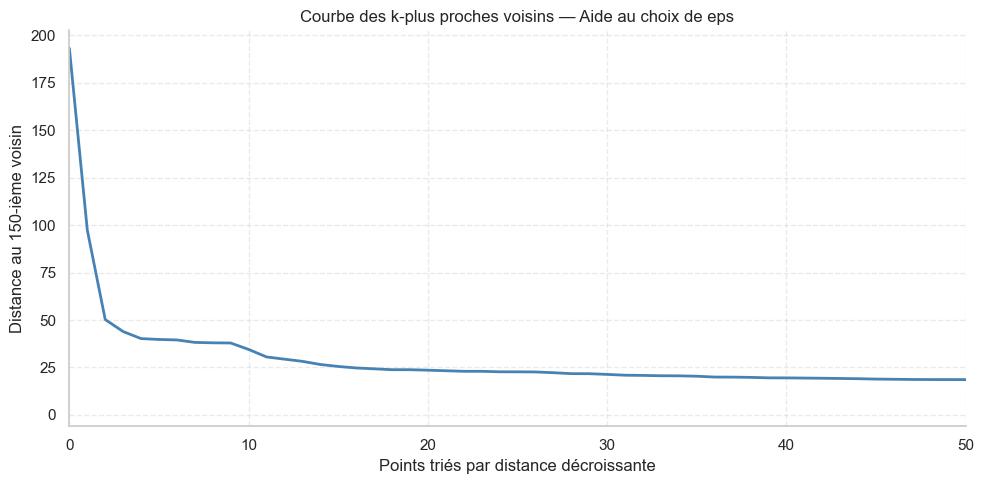

Observez le 'coude' de la courbe pour choisir une valeur d'eps appropriée.


In [39]:


# --- ÉTAPE 3 : K-NN Distance ---
min_samples = max(5, 2 * donnees_clustering.shape[1])
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(donnees_clustering)
distances, _ = nbrs.kneighbors(donnees_clustering)

# Tri et tracé (ton code original)
distances_k = np.sort(distances[:, -1])[::-1]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(distances_k, color="steelblue", linewidth=2)
ax.set_xlabel("Points triés par distance décroissante")
ax.set_ylabel(f"Distance au {min_samples}-ième voisin")
ax.set_title("Courbe des k-plus proches voisins — Aide au choix de eps")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.4)

# Zoom sur la zone du coude
ax.set_xlim(0, 50)

plt.tight_layout()
plt.show()

print("Observez le 'coude' de la courbe pour choisir une valeur d'eps appropriée.")

on choisit eps = 50 car la courbe se stabilise (elle n'a plus de gros changements de comportement)

In [41]:
# Choix des hyperparamètres (à ajuster selon la courbe ci-dessus)
eps_value = 30      # À ajuster selon le coude observé
min_samples_value = 10

# Application de DBSCAN
dbscan = DBSCAN(eps=eps_value, min_samples=min_samples_value)
labels_dbscan = dbscan.fit_predict(donnees_clustering)

# Résultats
n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise = np.sum(labels_dbscan == -1)
n_total = len(labels_dbscan)

print(f"Paramètres : eps={eps_value}, min_samples={min_samples_value}")
print(f"Nombre de clusters trouvés : {n_clusters}")
print(f"Points de bruit (label -1) : {n_noise} ({n_noise/n_total*100:.1f}%)")
print(f"Points classifiés         : {n_total - n_noise} ({(n_total-n_noise)/n_total*100:.1f}%)")

# Taille de chaque cluster
unique_labels, counts = np.unique(labels_dbscan, return_counts=True)
print("\nDistribution des clusters :")
for lbl, cnt in zip(unique_labels, counts):
    nom = "Bruit" if lbl == -1 else f"Cluster {lbl}"
    print(f"  {nom:12s}: {cnt:5d} communes ({cnt/n_total*100:.1f}%)")

Paramètres : eps=30, min_samples=10
Nombre de clusters trouvés : 1
Points de bruit (label -1) : 3 (0.0%)
Points classifiés         : 34867 (100.0%)

Distribution des clusters :
  Bruit       :     3 communes (0.0%)
  Cluster 0   : 34867 communes (100.0%)


In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

# ==========================================
# 1. PRÉPARATION DES DONNÉES CLUSTERS DBSCAN
# ==========================================
# On repart du dataframe de travail et on y rattache les labels DBSCAN
# (labels_dbscan doit être aligné avec df_travail)
df_carte_cluster = df_travail.reset_index().copy()
df_carte_cluster['codecommune'] = df_carte_cluster['codecommune'].astype(str).str.zfill(5)

# Rattachement des labels DBSCAN
df_carte_cluster['label_dbscan'] = labels_dbscan

# Colonne texte pour la légende : "Bruit" pour -1, "Cluster 0", "Cluster 1"...
def label_to_nom(lbl):
    return 'Bruit' if lbl == -1 else f'Cluster {lbl}'

df_carte_cluster['Nom_Cluster'] = df_carte_cluster['label_dbscan'].apply(label_to_nom)

# ==========================================
# 2. CHARGEMENT GEODATA & FUSION
# ==========================================
url_geojson = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/communes.geojson"
france_communes = gpd.read_file(url_geojson)

carte_data = france_communes.merge(df_carte_cluster, left_on='code', right_on='codecommune')

# ==========================================
# 3. CONFIGURATION DES COULEURS (dynamique)
# ==========================================
# Palette pour les clusters (autant de couleurs que de clusters trouvés)
cmap_clusters = plt.get_cmap('Set1', n_clusters)

couleurs_dict = {'Bruit': '#cccccc'}  # Gris pour le bruit
for i in range(n_clusters):
    couleurs_dict[f'Cluster {i}'] = mcolors.to_hex(cmap_clusters(i))

# Ordre : bruit en dernier pour qu'il apparaisse en bas de la légende
clusters_trouves = [f'Cluster {i}' for i in range(n_clusters)]
categories_finales = clusters_trouves + (['Bruit'] if n_noise > 0 else [])

couleurs_liste = [couleurs_dict[cat] for cat in categories_finales]
cmap_custom = mcolors.ListedColormap(couleurs_liste)

# ==========================================
# 4. AFFICHAGE DE LA CARTE
# ==========================================
fig, ax = plt.subplots(1, 1, figsize=(15, 15), dpi=150)

carte_data.plot(
    column='Nom_Cluster',
    ax=ax,
    categorical=True,
    categories=categories_finales,
    cmap=cmap_custom,
    legend=False,       # On gère la légende manuellement (plus de contrôle)
    linewidth=0,
    edgecolor='none',
    missing_kwds={      # Communes non fusionnées → gris clair
        'color': '#eeeeee',
        'label': 'Données manquantes'
    }
)

# Légende manuelle avec taille des clusters dans le label
handles = []
for cat in categories_finales:
    n = (df_carte_cluster['Nom_Cluster'] == cat).sum()
    pct = n / n_total * 100
    label_legende = f'{cat}  ({n:,} communes, {pct:.1f}%)'
    patch = mpatches.Patch(color=couleurs_dict[cat], label=label_legende)
    handles.append(patch)

ax.legend(
    handles=handles,
    title=f"DBSCAN — eps={eps_value}, min_samples={min_samples_value}",
    loc='upper left',
    bbox_to_anchor=(1, 1),
    frameon=False,
    fontsize=11,
    title_fontsize=12
)

# ==========================================
# 5. FINALISATION
# ==========================================
ax.set_axis_off()
plt.title(
    f"Carte de France — Clustering DBSCAN ({n_clusters} cluster(s) + bruit)",
    fontsize=16, fontweight='bold', pad=20
)

plt.tight_layout()
plt.show()

## Avec PCA

In [24]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


data_dbscan_pca = data.copy()  # Pour éviter de modifier l'original

### code Marwan pour charger et standardiser les données avant DBSCAN

In [37]:


# ==========================================
# 1. PRÉPARATION BLINDÉE DES DONNÉES
# ==========================================
# On part d'une copie propre pour ne pas abîmer vos données d'origine
df_travail = data.copy()

# On place explicitement les identifiants en index (s'ils existent encore en colonnes)
colonnes_id = ['codecommune', 'dep']
for col in colonnes_id:
    if col in df_travail.columns:
        # On utilise set_index pour les cacher, append=True pour ne pas écraser les précédents
        df_travail = df_travail.set_index(col, append=True)

# On force la sélection des nombres et on gère les infinis/NA
df_numerique = (
    df_travail.select_dtypes(include=[np.number]) # Exclusion stricte du texte
    .replace([np.inf, -np.inf], np.nan)           # Sécurité divisions par zéro
    .fillna(0)                                    # Remplacement des vides
)

# On normalise
scaler = StandardScaler()
matrice_scaled = scaler.fit_transform(df_numerique)
donnees_clustering = pd.DataFrame(
    matrice_scaled, 
    columns=df_numerique.columns, 
    index=df_numerique.index
)



ACP pour réduire de dimensions

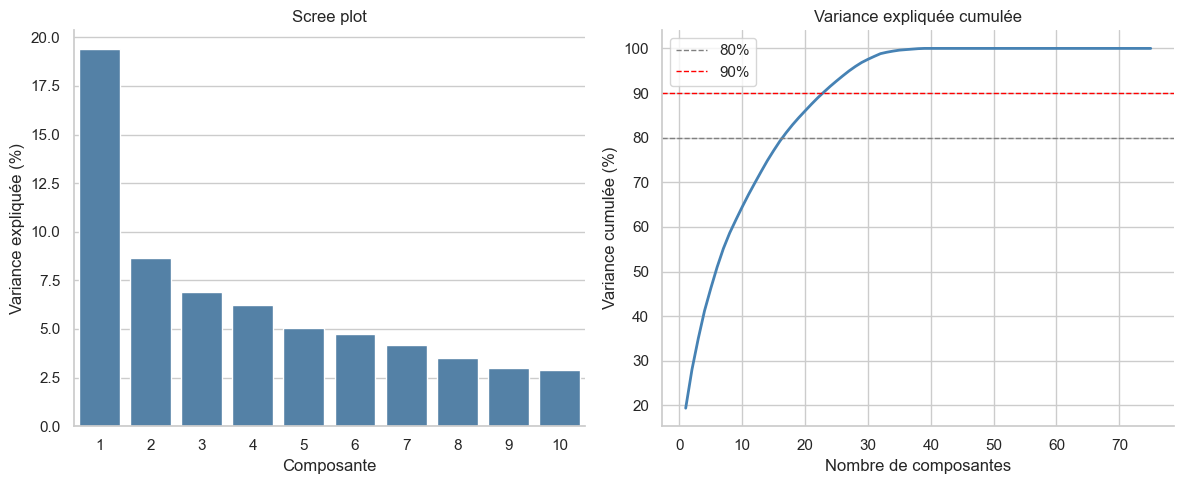

Nombre de composantes pour 80% de variance expliquée : 17
Variance expliquée par les 2 premières composantes : 28.1%


In [66]:
# ACP sur les données standardisées
pca_dbscan_pca = PCA()
data_pca = pca_dbscan_pca.fit_transform(donnees_clustering)

# Visualisation de la variance expliquée
explained = 100 * pca_dbscan_pca.explained_variance_ratio_
cumvar = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scree plot
sns.barplot(x=np.arange(1, 11), y=explained[:10], color="steelblue", ax=axes[0])
axes[0].set_xlabel("Composante")
axes[0].set_ylabel("Variance expliquée (%)")
axes[0].set_title("Scree plot")
axes[0].spines[["top", "right"]].set_visible(False)

# Variance cumulée
axes[1].plot(np.arange(1, len(cumvar) + 1), cumvar, color="steelblue", linewidth=2)
axes[1].axhline(80, color="gray", linestyle="--", linewidth=1, label="80%")
axes[1].axhline(90, color="red", linestyle="--", linewidth=1, label="90%")
axes[1].set_xlabel("Nombre de composantes")
axes[1].set_ylabel("Variance cumulée (%)")
axes[1].set_title("Variance expliquée cumulée")
axes[1].legend()
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

# Choix du nombre de composantes
n_comp = np.argmax(cumvar >= 80) + 1
print(f"Nombre de composantes pour 80% de variance expliquée : {n_comp}")
print(f"Variance expliquée par les 2 premières composantes : {cumvar[1]:.1f}%")

In [67]:
# n_comp = 10

# Réduction aux n_comp premières composantes
donnees_clustering_pca = data_pca[:, :n_comp]

# On garde aussi les 2 premières pour la visualisation
data_2d = data_pca[:, :2]

print(f"Données réduites : {donnees_clustering_pca.shape}")

Données réduites : (34870, 17)


Valeur de min_samples utilisée : 34


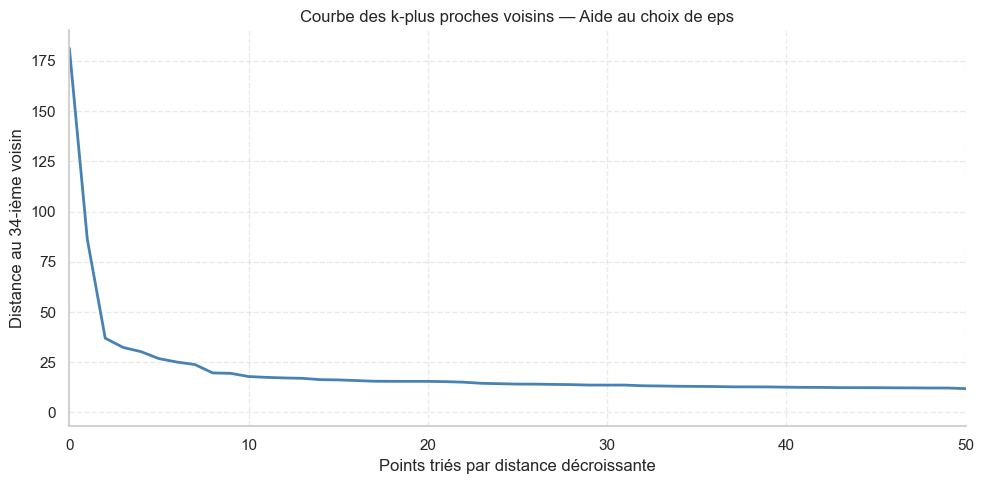

Observez le 'coude' de la courbe pour choisir une valeur d'eps appropriée.


In [68]:
from sklearn.neighbors import NearestNeighbors

# Méthode du k-ième plus proche voisin pour choisir eps
# On utilise min_samples = 2 * n_features comme règle empirique
min_samples = max(5, 2 * donnees_clustering_pca.shape[1])
print(f"Valeur de min_samples utilisée : {min_samples}")

# Calcul des distances au min_samples-ième plus proche voisin
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(donnees_clustering_pca)
distances, _ = nbrs.kneighbors(donnees_clustering_pca)

# On trie les distances au k-ième voisin (dernière colonne)
distances_k = np.sort(distances[:, -1])[::-1]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(distances_k, color="steelblue", linewidth=2)
ax.set_xlabel("Points triés par distance décroissante")
ax.set_ylabel(f"Distance au {min_samples}-ième voisin")
ax.set_title("Courbe des k-plus proches voisins — Aide au choix de eps")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.4)

# Zoom sur la zone du coude
ax.set_xlim(0, 50)

plt.tight_layout()
plt.show()

print("Observez le 'coude' de la courbe pour choisir une valeur d'eps appropriée.")

on choisit eps = 20 car la courbe se stabilise (elle n'a plus de gros changements de comportement)

In [69]:
# Choix des hyperparamètres (à ajuster selon la courbe ci-dessus)
eps_value_pca = 20      # À ajuster selon le coude observé
min_samples_value_pca = 10

# Application de DBSCAN
dbscan_pca = DBSCAN(eps=eps_value_pca, min_samples=min_samples_value_pca,
                algorithm='ball_tree', n_jobs=-1)
labels_dbscan_pca = dbscan_pca.fit_predict(donnees_clustering_pca)

# algorithme 'ball_tree' pour accélérer les calculs sur de grandes dimensions, n_jobs=-1 pour utiliser tous les cœurs

In [70]:
# Résultats
n_clusters_pca = len(set(labels_dbscan_pca)) - (1 if -1 in labels_dbscan_pca else 0)
n_noise_pca = np.sum(labels_dbscan_pca == -1)
n_total_pca = len(labels_dbscan_pca)

print(f"Paramètres : eps={eps_value}, min_samples={min_samples_value}")
print(f"Nombre de clusters trouvés : {n_clusters_pca}")
print(f"Points de bruit (label -1) : {n_noise_pca} ({n_noise_pca/n_total_pca*100:.1f}%)")
print(f"Points classifiés         : {n_total_pca - n_noise_pca} ({(n_total_pca-n_noise_pca)/n_total_pca*100:.1f}%)")

# Taille de chaque cluster
unique_labels, counts = np.unique(labels_dbscan_pca, return_counts=True)
print("\nDistribution des clusters :")
for lbl, cnt in zip(unique_labels, counts):
    nom = "Bruit" if lbl == -1 else f"Cluster {lbl}"
    print(f"  {nom:12s}: {cnt:5d} communes ({cnt/n_total*100:.1f}%)")

Paramètres : eps=20, min_samples=10
Nombre de clusters trouvés : 1
Points de bruit (label -1) : 4 (0.0%)
Points classifiés         : 34866 (100.0%)

Distribution des clusters :
  Bruit       :     4 communes (0.0%)
  Cluster 0   : 34866 communes (100.0%)


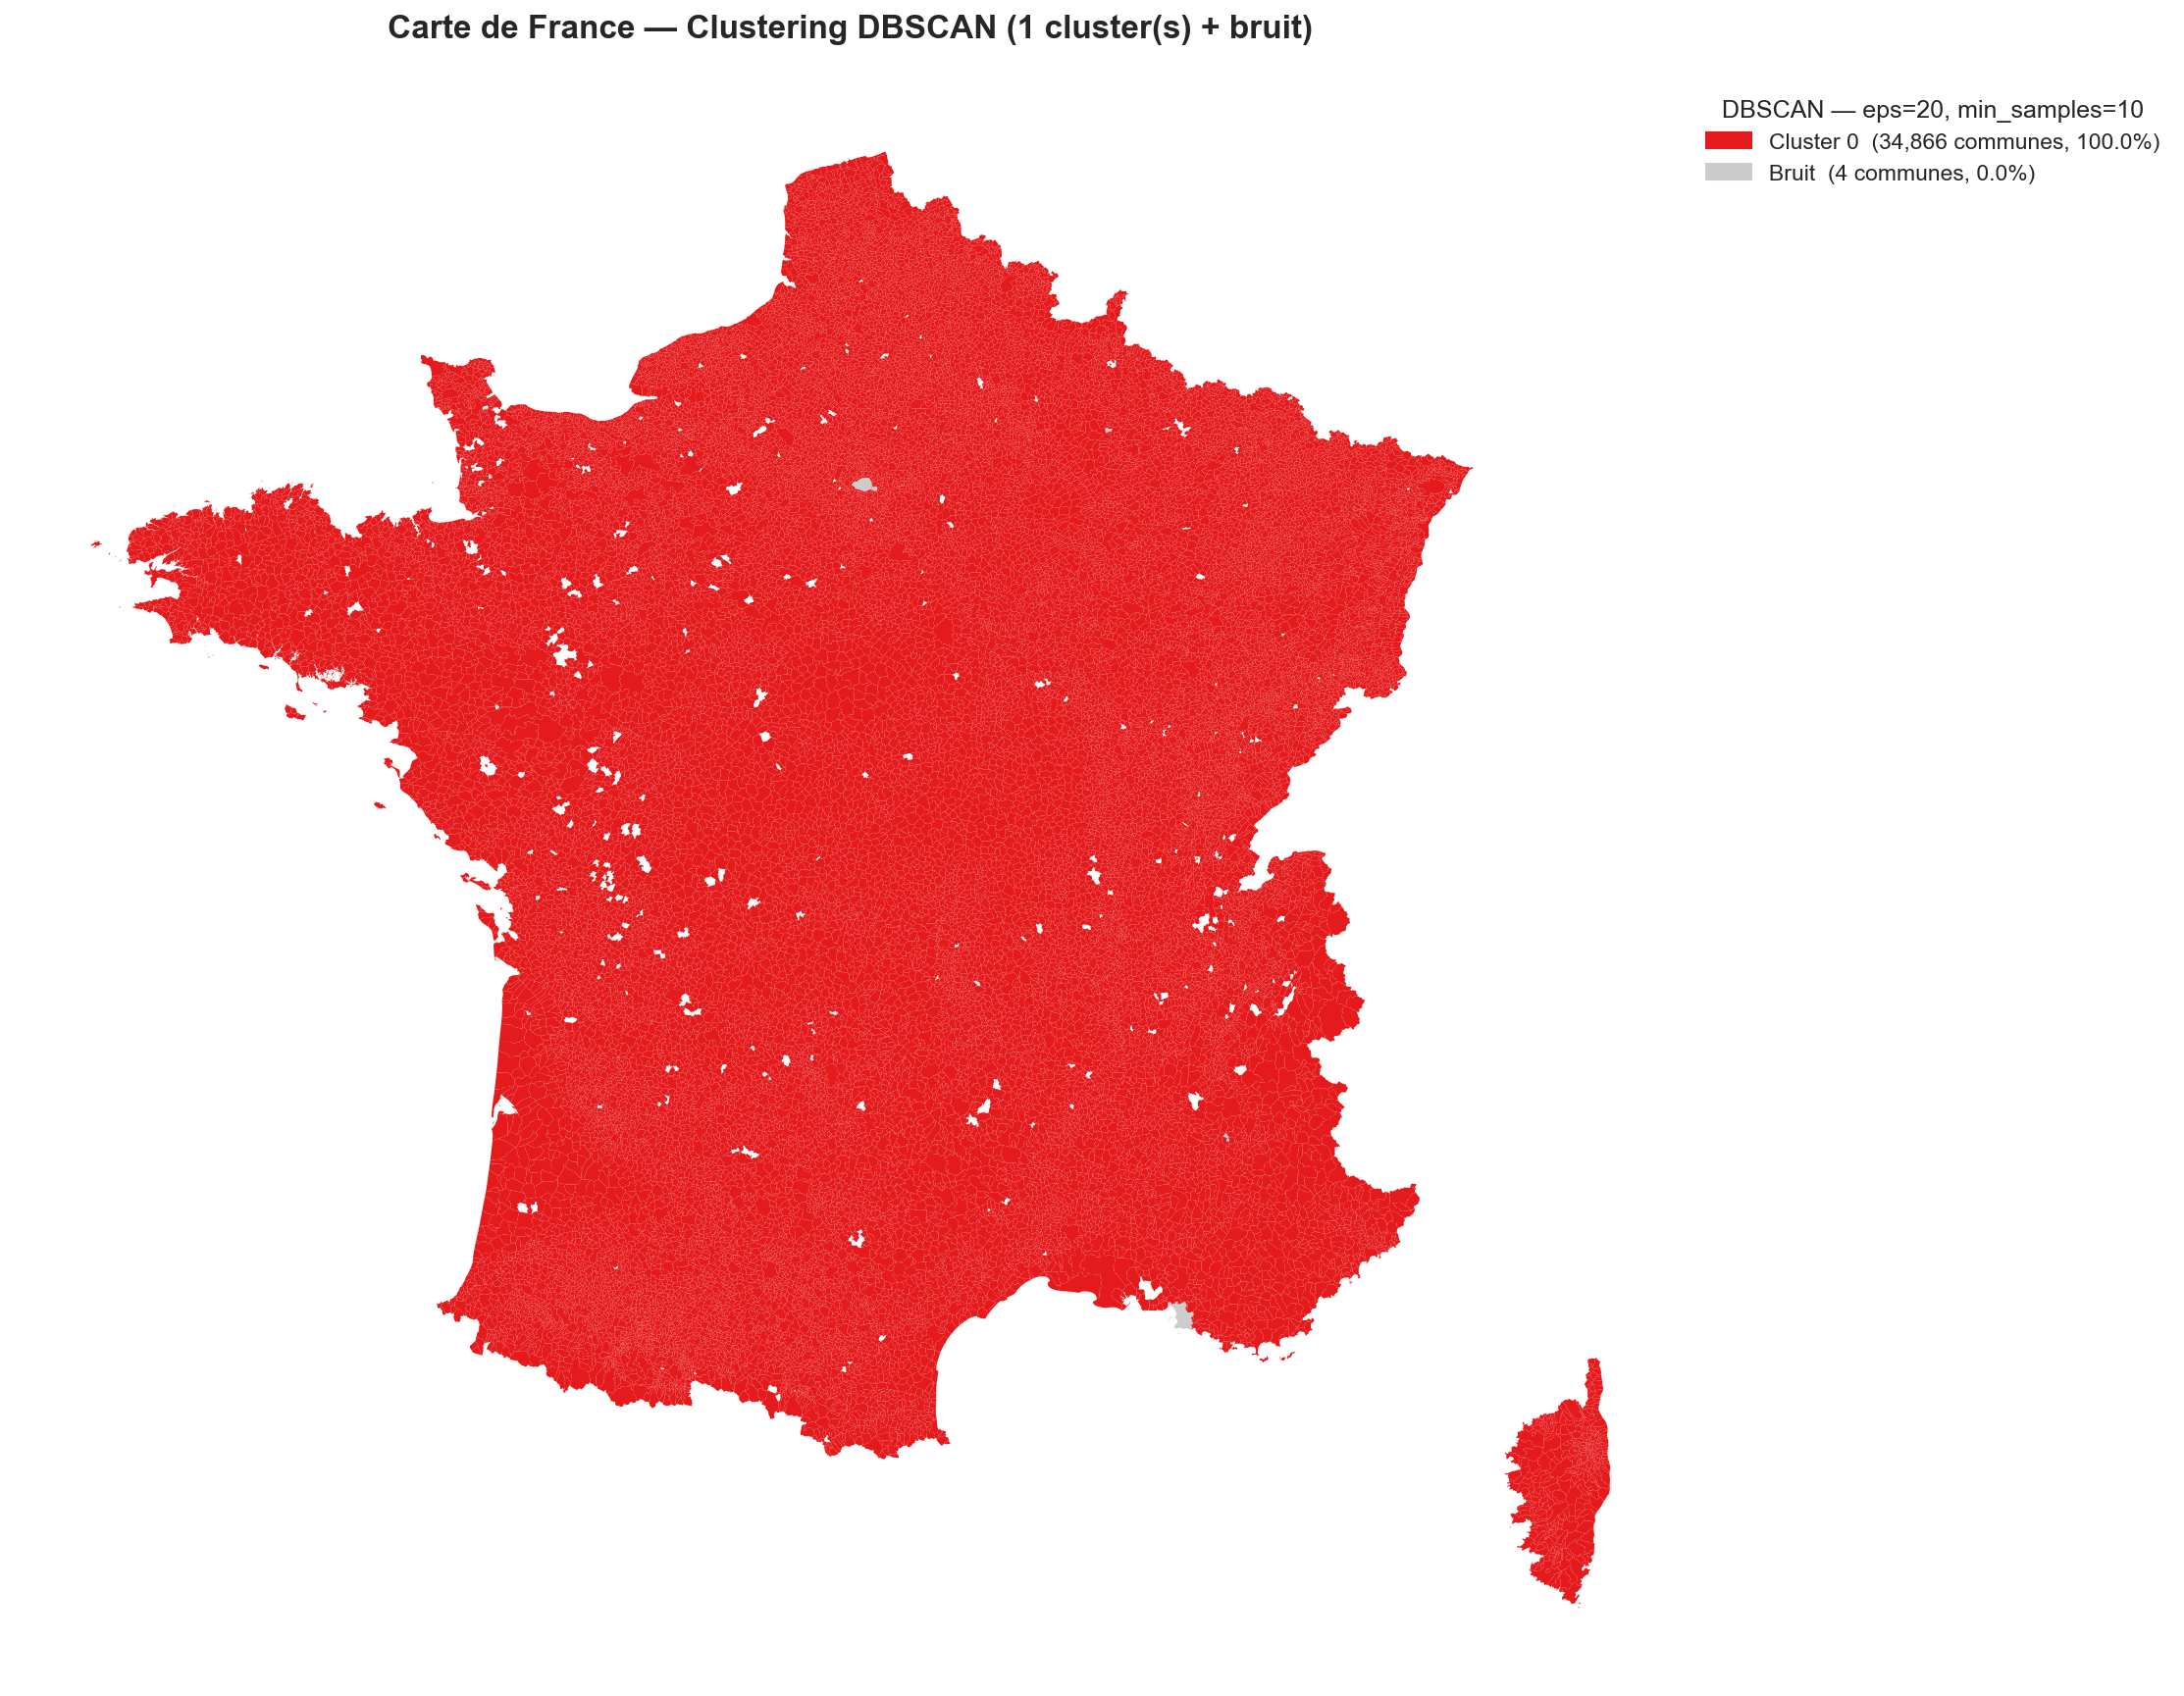

In [50]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

# ==========================================
# 1. PRÉPARATION DES DONNÉES CLUSTERS DBSCAN
# ==========================================
# On repart du dataframe de travail et on y rattache les labels DBSCAN
# (labels_dbscan doit être aligné avec df_travail)
df_carte_cluster_pca = df_travail.reset_index().copy()
df_carte_cluster_pca['codecommune'] = df_carte_cluster_pca['codecommune'].astype(str).str.zfill(5)

# Rattachement des labels DBSCAN
df_carte_cluster_pca['label_dbscan'] = labels_dbscan_pca

# Colonne texte pour la légende : "Bruit" pour -1, "Cluster 0", "Cluster 1"...
def label_to_nom(lbl):
    return 'Bruit' if lbl == -1 else f'Cluster {lbl}'

df_carte_cluster_pca['Nom_Cluster'] = df_carte_cluster_pca['label_dbscan'].apply(label_to_nom)

# ==========================================
# 2. CHARGEMENT GEODATA & FUSION
# ==========================================
url_geojson = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/communes.geojson"
france_communes = gpd.read_file(url_geojson)

carte_data = france_communes.merge(df_carte_cluster_pca, left_on='code', right_on='codecommune')

# ==========================================
# 3. CONFIGURATION DES COULEURS (dynamique)
# ==========================================
# Palette pour les clusters (autant de couleurs que de clusters trouvés)
cmap_clusters = plt.get_cmap('Set1', n_clusters_pca)

couleurs_dict = {'Bruit': '#cccccc'}  # Gris pour le bruit
for i in range(n_clusters_pca):
    couleurs_dict[f'Cluster {i}'] = mcolors.to_hex(cmap_clusters(i))

# Ordre : bruit en dernier pour qu'il apparaisse en bas de la légende
clusters_trouves = [f'Cluster {i}' for i in range(n_clusters_pca)]
categories_finales = clusters_trouves + (['Bruit'] if n_noise_pca > 0 else [])

couleurs_liste = [couleurs_dict[cat] for cat in categories_finales]
cmap_custom = mcolors.ListedColormap(couleurs_liste)

# ==========================================
# 4. AFFICHAGE DE LA CARTE
# ==========================================
fig, ax = plt.subplots(1, 1, figsize=(15, 15), dpi=150)

carte_data.plot(
    column='Nom_Cluster',
    ax=ax,
    categorical=True,
    categories=categories_finales,
    cmap=cmap_custom,
    legend=False,       # On gère la légende manuellement (plus de contrôle)
    linewidth=0,
    edgecolor='none',
    missing_kwds={      # Communes non fusionnées → gris clair
        'color': '#eeeeee',
        'label': 'Données manquantes'
    }
)

# Légende manuelle avec taille des clusters dans le label
handles = []
for cat in categories_finales:
    n = (df_carte_cluster_pca['Nom_Cluster'] == cat).sum()
    pct = n / n_total * 100
    label_legende = f'{cat}  ({n:,} communes, {pct:.1f}%)'
    patch = mpatches.Patch(color=couleurs_dict[cat], label=label_legende)
    handles.append(patch)

ax.legend(
    handles=handles,
    title=f"DBSCAN — eps={eps_value_pca}, min_samples={min_samples_value_pca}",
    loc='upper left',
    bbox_to_anchor=(1, 1),
    frameon=False,
    fontsize=11,
    title_fontsize=12
)

# ==========================================
# 5. FINALISATION
# ==========================================
ax.set_axis_off()
plt.title(
    f"Carte de France — Clustering DBSCAN ({n_clusters_pca} cluster(s) + bruit)",
    fontsize=16, fontweight='bold', pad=20
)

plt.tight_layout()
plt.show()

que ce soit avec ou sans la pca : DBSCAN donne 1 seul cluster ==> trop de données, trop de dimensions (apres acp dim=17), En haute dimension, toutes les distances tendent à devenir similaires — DBSCAN ne voit plus de zones denses vs creuses, tout lui semble "dense" de façon uniforme

methode compliquée à calibrer

## ACP en 2d

In [52]:
n_comp_2d = 2

# Réduction aux n_comp premières composantes
donnees_clustering_pca_2d = data_pca[:, :n_comp_2d]

# On garde aussi les 2 premières pour la visualisation
data_2d = data_pca[:, :2]

print(f"Données réduites : {donnees_clustering_pca_2d.shape}")

Données réduites : (34870, 2)


Valeur de min_samples utilisée : 5


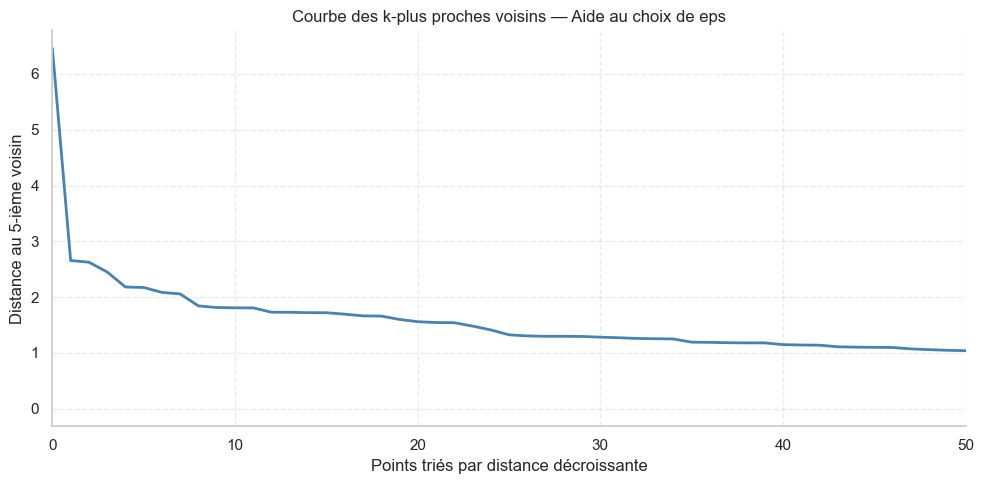

Observez le 'coude' de la courbe pour choisir une valeur d'eps appropriée.


In [53]:
from sklearn.neighbors import NearestNeighbors

# Méthode du k-ième plus proche voisin pour choisir eps
# On utilise min_samples = 2 * n_features comme règle empirique
min_samples = max(5, 2 * donnees_clustering_pca_2d.shape[1])
print(f"Valeur de min_samples utilisée : {min_samples}")

# Calcul des distances au min_samples-ième plus proche voisin
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(donnees_clustering_pca_2d)
distances, _ = nbrs.kneighbors(donnees_clustering_pca_2d)

# On trie les distances au k-ième voisin (dernière colonne)
distances_k = np.sort(distances[:, -1])[::-1]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(distances_k, color="steelblue", linewidth=2)
ax.set_xlabel("Points triés par distance décroissante")
ax.set_ylabel(f"Distance au {min_samples}-ième voisin")
ax.set_title("Courbe des k-plus proches voisins — Aide au choix de eps")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.4)

# Zoom sur la zone du coude
ax.set_xlim(0, 50)

plt.tight_layout()
plt.show()

print("Observez le 'coude' de la courbe pour choisir une valeur d'eps appropriée.")

In [57]:
# Choix des hyperparamètres (à ajuster selon la courbe ci-dessus)
eps_value_pca_2d = 2     # À ajuster selon le coude observé
min_samples_value_pca_2d = 10

# Application de DBSCAN
dbscan_pca_2d = DBSCAN(eps=eps_value_pca_2d, min_samples=min_samples_value_pca_2d)
labels_dbscan_pca_2d = dbscan_pca_2d.fit_predict(donnees_clustering_pca_2d)


In [58]:
# Résultats
n_clusters_pca_2d = len(set(labels_dbscan_pca_2d)) - (1 if -1 in labels_dbscan_pca_2d else 0)
n_noise_pca_2d = np.sum(labels_dbscan_pca_2d == -1)
n_total_pca_2d = len(labels_dbscan_pca_2d)

print(f"Paramètres : eps={eps_value_pca_2d}, min_samples={min_samples_value_pca_2d}")
print(f"Nombre de clusters trouvés : {n_clusters_pca_2d}")
print(f"Points de bruit (label -1) : {n_noise_pca_2d} ({n_noise_pca_2d/n_total_pca_2d*100:.1f}%)")
print(f"Points classifiés         : {n_total_pca_2d - n_noise_pca_2d} ({(n_total_pca_2d-n_noise_pca_2d)/n_total_pca_2d*100:.1f}%)")

# Taille de chaque cluster
unique_labels, counts = np.unique(labels_dbscan_pca_2d, return_counts=True)
print("\nDistribution des clusters :")
for lbl, cnt in zip(unique_labels, counts):
    nom = "Bruit" if lbl == -1 else f"Cluster {lbl}"
    print(f"  {nom:12s}: {cnt:5d} communes ({cnt/n_total_pca_2d*100:.1f}%)")

Paramètres : eps=2, min_samples=10
Nombre de clusters trouvés : 1
Points de bruit (label -1) : 6 (0.0%)
Points classifiés         : 34864 (100.0%)

Distribution des clusters :
  Bruit       :     6 communes (0.0%)
  Cluster 0   : 34864 communes (100.0%)


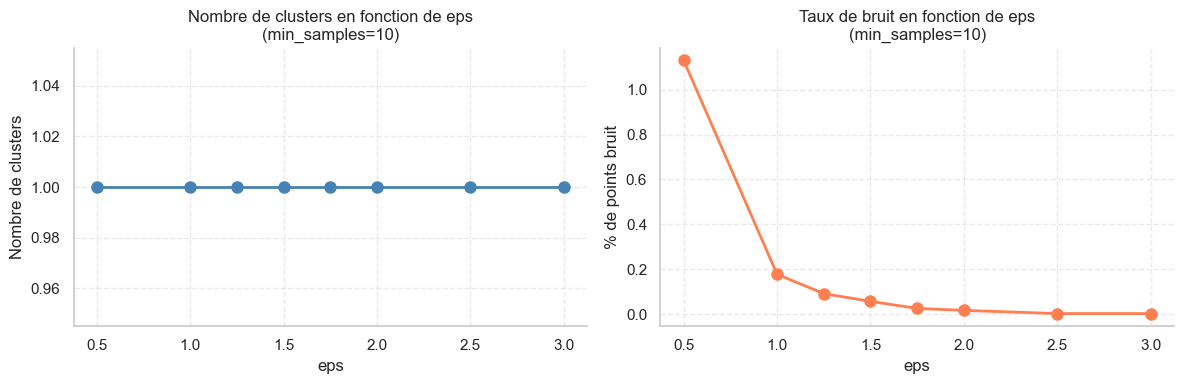

 eps  n_clusters  n_bruit  pct_bruit
0.50           1      394   1.129911
1.00           1       62   0.177803
1.25           1       32   0.091769
1.50           1       20   0.057356
1.75           1        9   0.025810
2.00           1        6   0.017207
2.50           1        1   0.002868
3.00           1        1   0.002868


In [61]:
# Grille de valeurs à tester
eps_values = [0.5, 1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0]
min_s = min_samples_value

resultats = []
for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=min_s)
    lbls = db.fit_predict(donnees_clustering_pca_2d)
    n_cl = len(set(lbls)) - (1 if -1 in lbls else 0)
    n_br = np.sum(lbls == -1)
    resultats.append({"eps": eps, "n_clusters": n_cl, "n_bruit": n_br,
                      "pct_bruit": n_br / len(lbls) * 100})

df_resultats = pd.DataFrame(resultats)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(df_resultats["eps"], df_resultats["n_clusters"],
             marker="o", color="steelblue", linewidth=2, markersize=8)
axes[0].set_xlabel("eps")
axes[0].set_ylabel("Nombre de clusters")
axes[0].set_title(f"Nombre de clusters en fonction de eps\n(min_samples={min_s})")
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].grid(True, linestyle="--", alpha=0.4)

axes[1].plot(df_resultats["eps"], df_resultats["pct_bruit"],
             marker="o", color="coral", linewidth=2, markersize=8)
axes[1].set_xlabel("eps")
axes[1].set_ylabel("% de points bruit")
axes[1].set_title(f"Taux de bruit en fonction de eps\n(min_samples={min_s})")
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

print(df_resultats.to_string(index=False))

même en testant plus de parametres eps (auquel DBSCAN est tres sensible), changement du bruit mais pas du nombre de clusters

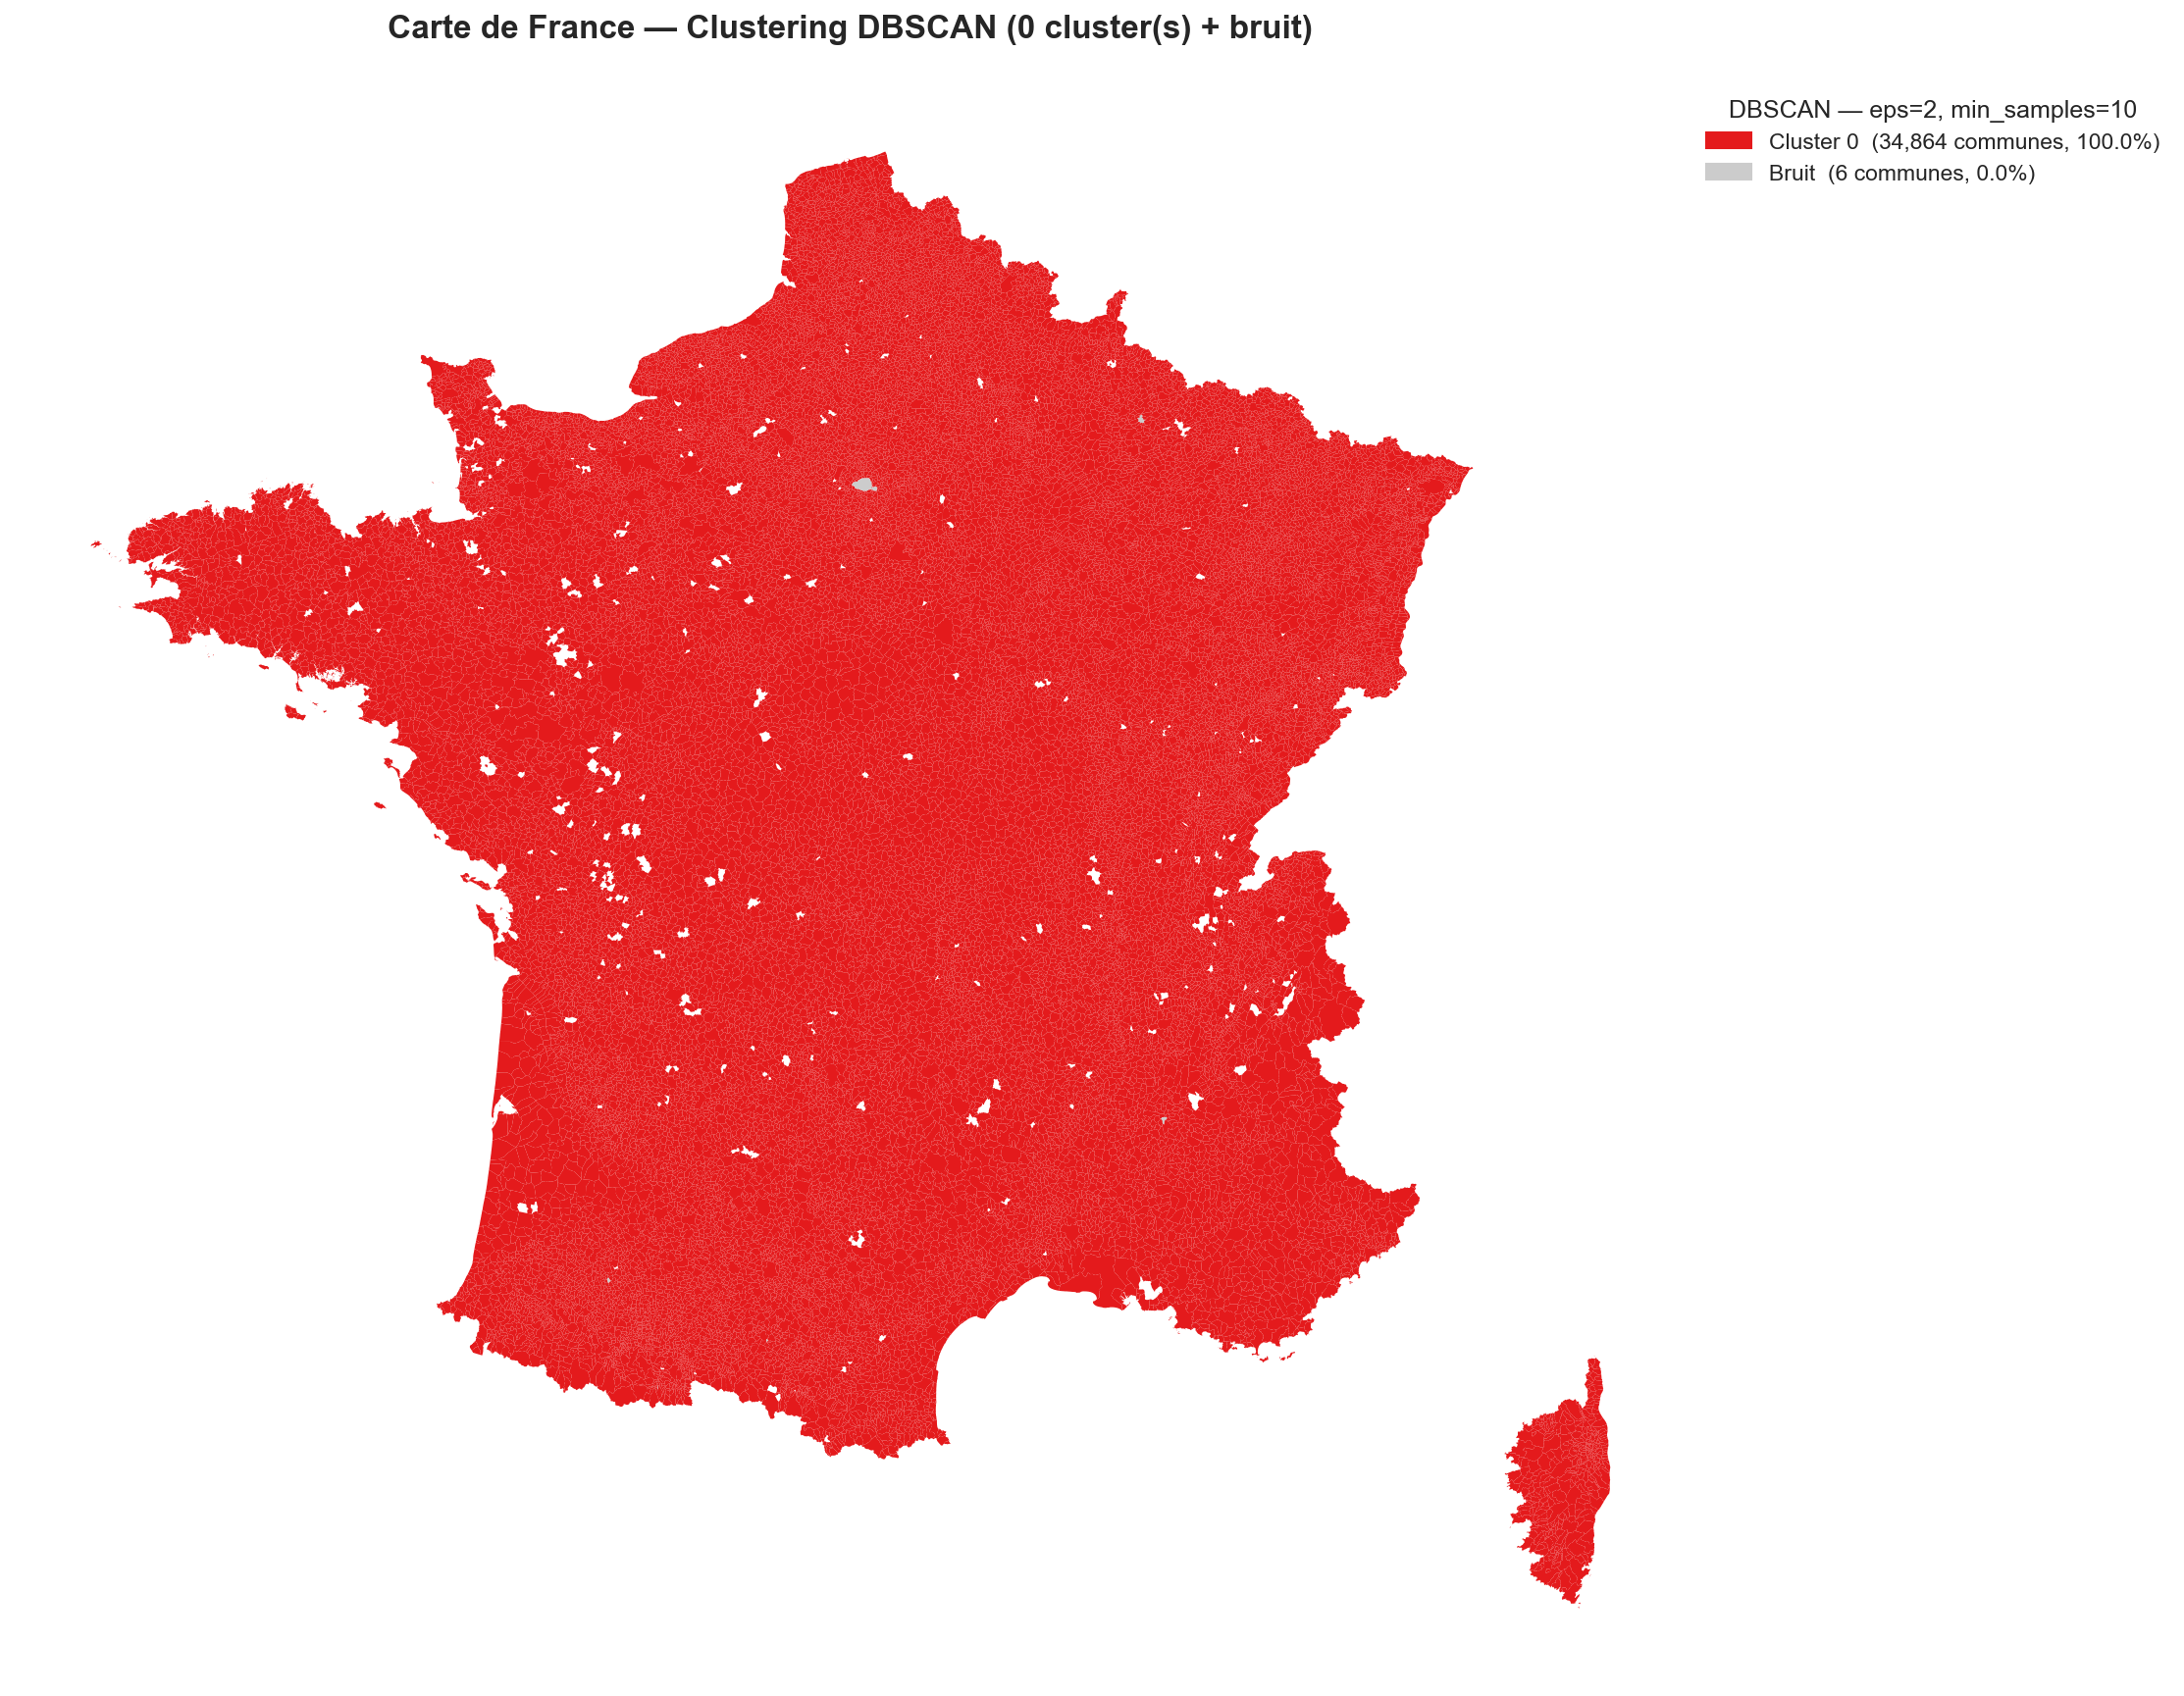

In [59]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

# ==========================================
# 1. PRÉPARATION DES DONNÉES CLUSTERS DBSCAN
# ==========================================
# On repart du dataframe de travail et on y rattache les labels DBSCAN
# (labels_dbscan doit être aligné avec df_travail)
df_carte_cluster_pca_2d = df_travail.reset_index().copy()
df_carte_cluster_pca_2d['codecommune'] = df_carte_cluster_pca_2d['codecommune'].astype(str).str.zfill(5)

# Rattachement des labels DBSCAN
df_carte_cluster_pca_2d['label_dbscan'] = labels_dbscan_pca_2d

# Colonne texte pour la légende : "Bruit" pour -1, "Cluster 0", "Cluster 1"...
def label_to_nom(lbl):
    return 'Bruit' if lbl == -1 else f'Cluster {lbl}'

df_carte_cluster_pca_2d['Nom_Cluster'] = df_carte_cluster_pca_2d['label_dbscan'].apply(label_to_nom)

# ==========================================
# 2. CHARGEMENT GEODATA & FUSION
# ==========================================
url_geojson = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/communes.geojson"
france_communes = gpd.read_file(url_geojson)

carte_data = france_communes.merge(df_carte_cluster_pca_2d, left_on='code', right_on='codecommune')

# ==========================================
# 3. CONFIGURATION DES COULEURS (dynamique)
# ==========================================
# Palette pour les clusters (autant de couleurs que de clusters trouvés)
cmap_clusters = plt.get_cmap('Set1', n_clusters_pca_2d)

couleurs_dict = {'Bruit': '#cccccc'}  # Gris pour le bruit
for i in range(n_clusters_pca_2d):
    couleurs_dict[f'Cluster {i}'] = mcolors.to_hex(cmap_clusters(i))

# Ordre : bruit en dernier pour qu'il apparaisse en bas de la légende
clusters_trouves = [f'Cluster {i}' for i in range(n_clusters_pca_2d)]
categories_finales = clusters_trouves + (['Bruit'] if n_noise_pca_2d > 0 else [])

couleurs_liste = [couleurs_dict[cat] for cat in categories_finales]
cmap_custom = mcolors.ListedColormap(couleurs_liste)

# ==========================================
# 4. AFFICHAGE DE LA CARTE
# ==========================================
fig, ax = plt.subplots(1, 1, figsize=(15, 15), dpi=150)

carte_data.plot(
    column='Nom_Cluster',
    ax=ax,
    categorical=True,
    categories=categories_finales,
    cmap=cmap_custom,
    legend=False,       # On gère la légende manuellement (plus de contrôle)
    linewidth=0,
    edgecolor='none',
    missing_kwds={      # Communes non fusionnées → gris clair
        'color': '#eeeeee',
        'label': 'Données manquantes'
    }
)

# Légende manuelle avec taille des clusters dans le label
handles = []
for cat in categories_finales:
    n = (df_carte_cluster_pca_2d['Nom_Cluster'] == cat).sum()
    pct = n / n_total_pca_2d * 100
    label_legende = f'{cat}  ({n:,} communes, {pct:.1f}%)'
    patch = mpatches.Patch(color=couleurs_dict[cat], label=label_legende)
    handles.append(patch)

ax.legend(
    handles=handles,
    title=f"DBSCAN — eps={eps_value_pca_2d}, min_samples={min_samples_value_pca_2d}",
    loc='upper left',
    bbox_to_anchor=(1, 1),
    frameon=False,
    fontsize=11,
    title_fontsize=12
)

# ==========================================
# 5. FINALISATION
# ==========================================
ax.set_axis_off()
plt.title(
    f"Carte de France — Clustering DBSCAN ({n_clusters_pca} cluster(s) + bruit)",
    fontsize=16, fontweight='bold', pad=20
)

plt.tight_layout()
plt.show()

meme dbscan en 2d n'est pas concluant

pas possible de faire de score de silhouette (pas assez de clusters (minimimum 2))

NOTES pour les vacances :

spectral, DBSCAN, AHC (?)

### AHC

In [ ]:
# code Marwan pour charger et standardiser les données avant DBSCAN

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. PRÉPARATION BLINDÉE DES DONNÉES
# ==========================================
# On part d'une copie propre pour ne pas abîmer vos données d'origine
df_travail = data.copy()

# On place explicitement les identifiants en index (s'ils existent encore en colonnes)
colonnes_id = ['codecommune', 'dep']
for col in colonnes_id:
    if col in df_travail.columns:
        # On utilise set_index pour les cacher, append=True pour ne pas écraser les précédents
        df_travail = df_travail.set_index(col, append=True)

# On force la sélection des nombres et on gère les infinis/NA
df_numerique = (
    df_travail.select_dtypes(include=[np.number]) # Exclusion stricte du texte
    .replace([np.inf, -np.inf], np.nan)           # Sécurité divisions par zéro
    .fillna(0)                                    # Remplacement des vides
)

# On normalise
scaler = StandardScaler()
matrice_scaled = scaler.fit_transform(df_numerique)
donnees_clustering = pd.DataFrame(
    matrice_scaled, 
    columns=df_numerique.columns, 
    index=df_numerique.index
)

